# Habitat suitability modelling for female brown bears with cubs in the Pyrenees

## A spatially explicit and reproducible species distribution modelling workflow

This notebook develops a complete habitat suitability analysis for female brown bears (*Ursus arctos*) accompanied by cubs. Two age classes are modelled independently because cub age is associated with different periods of the annual cycle and potentially different habitat requirements:

- cubs younger than six months (`lt6`);
- cubs between six and twelve months (`6to12`).

The analysis combines GPS observations, independent field observations, and a 100 m environmental raster dataset covering the Pyrenees. It compares regional and locally accessible background definitions, evaluates transferability to unseen individuals, quantifies several components of predictive uncertainty, and generates continuous suitability and categorical habitat-zone maps.


## Analytical structure

1. **Study configuration and reproducibility**
2. **Environmental dataset inspection**
3. **Biological data preparation**
4. **Spatial domains and background sampling**
5. **Seasonal predictor extraction and model-table diagnostics**
6. **Model evaluation criteria and algorithms**
7. **Nested leave-one-individual-out validation**
8. **Final fitting, calibration, and random-split comparison**
9. **Spatial prediction, novelty, and uncertainty**
10. **Habitat zones, model interpretation, and independent validation**
11. **Final verification and conclusions**

The principal validation design is leave-one-individual-out cross-validation. This evaluates whether a model fitted with some monitored bears can transfer to a bear that was completely absent from training. Repeated random train/test splitting is retained only as a methodological comparison because it does not protect against dependence among fixes from the same individual and trajectory.

# 1. Study configuration and reproducibility

## 1.1 Computational environment and analysis controls

The notebook is designed for the `pirineus-raster` kernel. The default settings correspond to the complete analysis reported in this study.

Tree-based models are fitted using predictors in their original units. Random Forest and XGBoost partition variables through ordered split thresholds. Retaining natural units also improves the interpretation of environmental diagnostics.

In [1]:
# Output management
OUTPUT_BASE = "outputs/ursus_arctos_habitat_modelling"
OUTPUT_DIR = None  # None creates the next available run_N directory.
PROJECT_ROOT_OVERRIDE = None  # Set an absolute repository path only if automatic discovery fails.

# Reproducibility and sampling
RANDOM_SEED = 1714
N_BACKGROUND_TRAIN = 10_000
N_BACKGROUND_TEST = 2_000
MIN_THIN_DISTANCE_M = 100
N_THIN_ITERATIONS = 20

# Accessible-domain definition
LOCAL_BUFFER_KM = 25.0
LOCAL_BUFFER_SENSITIVITY_KM = (20.0, 25.0, 30.0)
CUSTOM_LOCAL_DOMAIN_PATH = None

# Model fitting and validation
N_FINAL_BOOTSTRAP_REPLICATES = 10
N_EVALUATION_REPLICATES = 5
N_PAPER_VALIDATION_REPEATS = 10
RUN_TUNING = True
STRICT_NESTED_TUNING = True
N_RF_TUNING_ITER = 12
N_OPTUNA_TRIALS = 20
INNER_BLOCKS_AXIS = 2

# Optional components
RUN_XGBOOST = True
RUN_MAP_PREDICTION = True
RUN_SHAP = True
SMOKE_MODE = False  # Reduced computational validation only; keep False for the scientific analysis.
BATCH_SIZE = 100_000

## 1.2 Imports and shared definitions

The analysis uses Rasterio for gridded data, Shapely and PyProj for spatial geometry and reprojection, scikit-learn and XGBoost for modelling, Optuna for hyperparameter search, and SHAP for algorithm-specific interpretation.

In [2]:
import json
import logging
import math
import os
import pickle
import subprocess
import sys
from pathlib import Path
from types import SimpleNamespace
from typing import Any, Iterable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import yaml
from IPython.display import Image, Markdown, display
from pyproj import Transformer
from rasterio.enums import Resampling
from rasterio.features import geometry_mask
from rasterio.transform import rowcol, xy
from rasterio.vrt import WarpedVRT
from rasterio.windows import Window
from scipy import ndimage
from scipy.spatial import cKDTree
from scipy.stats import mannwhitneyu, spearmanr
from shapely.geometry import MultiPoint, Point, box, mapping, shape
from shapely.ops import transform as transform_geometry
from shapely.ops import unary_union
from sklearn.ensemble import RandomForestClassifier
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    log_loss,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import ParameterSampler, StratifiedGroupKFold

try:
    import joblib
except ImportError:
    joblib = None

try:
    import optuna
except ImportError:
    optuna = None

try:
    import shap
except ImportError:
    shap = None

try:
    import xgboost
except ImportError:
    xgboost = None


CUB_CLASSES = ("lt6", "6to12")
SEASON_ORDER = ("winter", "spring", "summer", "autumn")
SEASON_MONTHS = {
    "winter": {12, 1, 2},
    "spring": {3, 4, 5},
    "summer": {6, 7, 8},
    "autumn": {9, 10, 11},
}
CUB_CLASS_MAP = {"<6month": "lt6", "1": "6to12", "1.0": "6to12"}
REDUCED_FEATURE_EXCLUSIONS = {
    "topography_roughness",
    "topography_slope",
    "climate_max_temperature",
    "climate_min_temperature",
    "habitat_tree_cover_density",
}
SHORT_FEATURE_LABELS = {
    "climate_precipitation_annual": "Annual precipitation",
    "climate_solar_radiation_annual": "Annual solar radiation",
    "climate_mean_temperature": "Mean temperature",
    "climate_snow_cover": "Snow cover",
    "climate_water_availability": "Water availability",
    "topography_dem_elevation": "Elevation",
    "topography_ruggedness": "Ruggedness",
    "topography_tpi_macro": "Broad-scale TPI",
    "topography_tpi_med": "Medium-scale TPI",
    "topography_aspect_sin": "Aspect (north-south)",
    "topography_aspect_cos": "Aspect (east-west)",
    "human_logdistance_tracks": "Distance to tracks",
    "human_logdistance_towns": "Distance to towns",
    "human_logdistance_secondary_roads_transport_secondary_roads_distance": "Distance to secondary roads",
    "human_population_density_mean": "Population density",
    "human_landuse_presence": "Human land use",
    "habitat_biomass_mean": "Biomass",
    "habitat_productivity_mean": "Productivity",
    "habitat_broadleaf": "Broadleaf forest",
    "habitat_coniferous_dominant_leaf_type": "Coniferous forest",
    "habitat_mix_forest_habitat_broadleaf_habitat_coniferous_dominant_leaf_type": "Mixed forest",
    "habitat_grasslands": "Grassland",
    "habitat_shrubland_2018": "Shrubland",
    "habitat_screes_and_bare_rocks_2018": "Scree and bare rock",
}

/home/usuaris/csl/aniol.garriga.torra/.conda/envs/pirineus-raster/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1.3 Project paths, run directory, and logging

Every execution is isolated in a numeric `run_N` directory. Tables, plots, rasters, models, logs, and intermediate data are therefore never mixed with an earlier execution. This is essential when model settings or environmental predictors change between runs.

In [3]:
if sys.version_info < (3, 11):
    raise RuntimeError(
        "This notebook requires the 'pirineus-raster' Python 3.11 kernel. "
        f"The current kernel is Python {sys.version.split()[0]}."
    )


def find_project_root(start: Path, override: str | None = None) -> Path:
    """Locate the repository, with an explicit override for unusual Jupyter launch locations."""
    if override is not None:
        candidate = Path(override).expanduser().resolve()
        if (candidate / "pyproject.toml").exists() and (candidate / "configs").exists():
            return candidate
        raise FileNotFoundError(
            f"PROJECT_ROOT_OVERRIDE does not identify the pirineus-raster repository: {candidate}"
        )

    resolved = start.expanduser().resolve()
    for candidate in (resolved, *resolved.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "configs").exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate the pirineus-raster repository from the kernel working directory "
        f"({resolved}). Set PROJECT_ROOT_OVERRIDE in the configuration cell to the absolute repository path."
    )


def setup_logger(log_path: Path) -> logging.Logger:
    logger = logging.getLogger("ursus_arctos_habitat")
    logger.setLevel(logging.INFO)
    logger.handlers.clear()
    formatter = logging.Formatter("%(asctime)s | %(levelname)s | %(message)s")
    stream = logging.StreamHandler()
    stream.setFormatter(formatter)
    file_handler = logging.FileHandler(log_path)
    file_handler.setFormatter(formatter)
    logger.addHandler(stream)
    logger.addHandler(file_handler)
    return logger


def allocate_run_directory(project_root: Path, output_base: str, requested: str | None = None) -> Path:
    """Create a new run directory without overwriting an earlier analysis."""
    if requested is not None:
        destination = (project_root / requested).resolve()
        if destination.exists():
            raise FileExistsError(
                f"The requested output directory already exists: {destination}. "
                "Set OUTPUT_DIR = None to allocate the next run_N, or choose a new directory name."
            )
        destination.mkdir(parents=True)
        return destination

    base = project_root / output_base
    base.mkdir(parents=True, exist_ok=True)
    run_number = 1
    while (base / f"run_{run_number}").exists():
        run_number += 1
    destination = base / f"run_{run_number}"
    destination.mkdir()
    return destination


PROJECT_ROOT = find_project_root(Path.cwd(), globals().get("PROJECT_ROOT_OVERRIDE"))
os.chdir(PROJECT_ROOT)

# Re-executing this cell in the same kernel reuses the current empty/active run
# instead of allocating another directory. Restarting the kernel creates a new run.
if "RUN_ROOT" in globals() and Path(RUN_ROOT).exists():
    RUN_ROOT = Path(RUN_ROOT)
    print(f"Reusing run directory from the current kernel session: {RUN_ROOT}")
else:
    RUN_ROOT = allocate_run_directory(PROJECT_ROOT, OUTPUT_BASE, OUTPUT_DIR)

TABLE_DIR = RUN_ROOT / "tables"
PLOT_DIR = RUN_ROOT / "plots"
MAP_DIR = RUN_ROOT / "maps"
MODEL_DIR = RUN_ROOT / "models"
LOG_DIR = RUN_ROOT / "logs"
INTERMEDIATE_DIR = RUN_ROOT / "intermediate"
for directory in (TABLE_DIR, PLOT_DIR, MAP_DIR, MODEL_DIR, LOG_DIR, INTERMEDIATE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

paths = SimpleNamespace(
    root=RUN_ROOT,
    tables=TABLE_DIR,
    plots=PLOT_DIR,
    maps=MAP_DIR,
    models=MODEL_DIR,
    logs=LOG_DIR,
    intermediate=INTERMEDIATE_DIR,
)
logger = setup_logger(LOG_DIR / "sdm_bears.log")

print(f"Project root: {PROJECT_ROOT}")
print(f"Current run: {RUN_ROOT}")

Project root: /mnt/csl/work/aniol.garriga.torra/pirineus_raster
Current run: /mnt/csl/work/aniol.garriga.torra/pirineus_raster/outputs/ursus_arctos_habitat_modelling/run_3


## 1.4 Input data and effective configuration

The grid and all analytical rasters use EPSG:3035, a metric coordinate reference system suitable for 100 m resolution, distance calculations, buffering, and area measurement. Longitude and latitude are used only for presentation maps.

In [4]:
RASTER_DIR = PROJECT_ROOT / "data_processed/datasets/ursus_arctos_pyrenees_100m/rasters"
GPS_PATH = PROJECT_ROOT / "data_processed/notebooks/ursus_arctos_project/GPS_female_bears_with_cubs.csv"
OBS_PATH = PROJECT_ROOT / "data_processed/notebooks/ursus_arctos_project/observations_female_bears_with_cubs.csv"
INDIVIDUALS_PATH = PROJECT_ROOT / "data_processed/notebooks/ursus_arctos_project/bear_individuals.csv"
GRID_PATH = PROJECT_ROOT / "data_interim/grids/grid_ursus_arctos_pyrenees_100m.tif"
AOI_CONFIG_PATH = PROJECT_ROOT / "configs/aoi/ursus_arctos_pyrenees.yaml"
RUN_CONFIG_PATH = PROJECT_ROOT / "configs/runs/ursus_arctos_pyrenees_100m.yaml"

with AOI_CONFIG_PATH.open(encoding="utf-8") as file:
    aoi_config = yaml.safe_load(file)

TARGET_CRS = aoi_config["crs"]
BOUNDS_4326 = aoi_config["bounds_epsg4326"]

config = SimpleNamespace(
    random_seed=RANDOM_SEED,
    n_background_train=N_BACKGROUND_TRAIN,
    n_background_test=N_BACKGROUND_TEST,
    min_thin_distance_m=MIN_THIN_DISTANCE_M,
    n_thin_iterations=N_THIN_ITERATIONS,
    local_buffer_km=LOCAL_BUFFER_KM,
    local_buffer_sensitivity_km=tuple(LOCAL_BUFFER_SENSITIVITY_KM),
    custom_local_domain_path=CUSTOM_LOCAL_DOMAIN_PATH,
    n_final_bootstrap_replicates=N_FINAL_BOOTSTRAP_REPLICATES,
    n_evaluation_replicates=N_EVALUATION_REPLICATES,
    n_paper_validation_repeats=N_PAPER_VALIDATION_REPEATS,
    n_rf_tuning_iter=N_RF_TUNING_ITER,
    n_optuna_trials=N_OPTUNA_TRIALS,
    inner_blocks_axis=INNER_BLOCKS_AXIS,
    run_tuning=RUN_TUNING,
    strict_nested_tuning=STRICT_NESTED_TUNING,
    run_xgboost=RUN_XGBOOST,
    run_shap=RUN_SHAP,
    run_map_prediction=RUN_MAP_PREDICTION,
    smoke_mode=SMOKE_MODE,
    batch_size=BATCH_SIZE,
    prediction_season_by_class={"lt6": "spring", "6to12": "summer"},
)

if config.smoke_mode:
    config.n_background_train = min(config.n_background_train, 1_000)
    config.n_background_test = min(config.n_background_test, 300)
    config.n_final_bootstrap_replicates = min(config.n_final_bootstrap_replicates, 2)
    config.n_evaluation_replicates = 1
    config.n_paper_validation_repeats = 2
    config.n_rf_tuning_iter = min(config.n_rf_tuning_iter, 2)
    config.n_optuna_trials = min(config.n_optuna_trials, 2)
    config.run_shap = False
    config.run_map_prediction = False

display(pd.DataFrame({"parameter": vars(config).keys(), "value": vars(config).values()}))

,parameter,value
0,random_seed,1714
1,n_background_train,10000
2,n_background_test,2000
3,min_thin_distance_m,100
4,n_thin_iterations,20
5,local_buffer_km,25.0
6,local_buffer_sensitivity_km,"(20.0, 25.0, 30.0)"
7,custom_local_domain_path,None
8,n_final_bootstrap_replicates,10
9,n_evaluation_replicates,5


# 2. Environmental dataset inspection

## 2.1 Raster inventory and temporal structure

Each environmental raster is identified using the variable name stored in its metadata. Seasonal source rasters are grouped under a common model variable, allowing the observation date to determine which seasonal layer is sampled. Static and annual predictors are used directly.

The inventory records the spatial reference, dimensions, resolution, data type, nodata value, temporal role, and source-file timestamp for every layer.

In [5]:
def safe_variable_name(name: Any) -> str:
    cleaned = str(name).strip().replace(" ", "_").replace("-", "_")
    return "_".join(part for part in cleaned.split("_") if part).lower()


def feature_name_from_path(path: Path) -> str:
    name = path.stem
    for suffix in ("_ursus_arctos_pyrenees_100m", "_pyrenees_100m", "_100m"):
        if name.endswith(suffix):
            name = name[: -len(suffix)]
    return name


def infer_temporal_metadata(variable: str) -> dict[str, Any]:
    variable = safe_variable_name(variable)
    tokens = variable.split("_")
    season = next((item for item in SEASON_ORDER if item in tokens), None)
    if variable.startswith("climate_snow_cover_") and season:
        return {"model_variable": "climate_snow_cover", "temporal_dimension": season, "temporal_role": "seasonal"}
    if season and tokens[-1] == season:
        return {"model_variable": "_".join(tokens[:-1]), "temporal_dimension": season, "temporal_role": "seasonal"}
    if tokens[-1] == "annual":
        return {"model_variable": variable, "temporal_dimension": "annual", "temporal_role": "annual"}
    return {"model_variable": variable, "temporal_dimension": None, "temporal_role": "static"}


def load_raster_inventory(raster_dir: Path) -> pd.DataFrame:
    records: list[dict[str, Any]] = []
    for path in sorted([*raster_dir.glob("*.tif"), *raster_dir.glob("*.tiff")]):
        metadata_path = path.with_suffix(".json")
        metadata = json.loads(metadata_path.read_text()) if metadata_path.exists() else {}
        variable = safe_variable_name(metadata.get("variable") or feature_name_from_path(path))
        temporal = infer_temporal_metadata(variable)
        with rasterio.open(path) as src:
            records.append(
                {
                    "path": str(path),
                    "variable": variable,
                    **temporal,
                    "unit": metadata.get("unit"),
                    "description": metadata.get("variable_description") or metadata.get("description"),
                    "crs": str(src.crs),
                    "width": src.width,
                    "height": src.height,
                    "res_x": src.res[0],
                    "res_y": src.res[1],
                    "nodata": src.nodata,
                    "dtype": src.dtypes[0],
                    "modified_utc": pd.to_datetime(path.stat().st_mtime, unit="s", utc=True),
                }
            )
    if not records:
        raise FileNotFoundError(f"No environmental rasters found in {raster_dir}")
    return pd.DataFrame(records)

In [6]:
inventory = load_raster_inventory(RASTER_DIR)
inventory.to_csv(TABLE_DIR / "environmental_raster_inventory.csv", index=False)
inventory.loc[inventory["temporal_role"] == "seasonal"].to_csv(
    TABLE_DIR / "environmental_temporal_variables.csv", index=False
)

inventory_summary = (
    inventory.groupby(["model_variable", "temporal_role"], dropna=False)
    .agg(n_source_rasters=("path", "size"), dimensions=("temporal_dimension", lambda values: ", ".join(sorted(values.dropna().astype(str).unique()))))
    .reset_index()
)
display(inventory_summary)
display(inventory.loc[inventory["temporal_role"] == "seasonal", ["variable", "model_variable", "temporal_dimension", "unit"]])

,model_variable,temporal_role,n_source_rasters,dimensions
0,climate_max_temperature,seasonal,4,"autumn, spring, summer, winter"
1,climate_mean_temperature,seasonal,4,"autumn, spring, summer, winter"
2,climate_min_temperature,seasonal,4,"autumn, spring, summer, winter"
3,climate_precipitation_annual,annual,1,annual
4,climate_snow_cover,seasonal,2,"spring, winter"
5,climate_solar_radiation_annual,annual,1,annual
6,climate_water_availability,seasonal,4,"autumn, spring, summer, winter"
7,habitat_biomass_mean,static,1,
8,habitat_broadleaf,static,1,
9,habitat_coniferous_dominant_leaf_type,static,1,


,variable,model_variable,temporal_dimension,unit
0,climate_max_temperature_autumn,climate_max_temperature,autumn,NaN
1,climate_max_temperature_spring,climate_max_temperature,spring,NaN
2,climate_max_temperature_summer,climate_max_temperature,summer,NaN
3,climate_max_temperature_winter,climate_max_temperature,winter,NaN
4,climate_mean_temperature_autumn,climate_mean_temperature,autumn,NaN
5,climate_mean_temperature_spring,climate_mean_temperature,spring,NaN
6,climate_mean_temperature_summer,climate_mean_temperature,summer,NaN
7,climate_mean_temperature_winter,climate_mean_temperature,winter,NaN
8,climate_min_temperature_autumn,climate_min_temperature,autumn,NaN
9,climate_min_temperature_spring,climate_min_temperature,spring,NaN


## 2.2 Grid alignment and environmental completeness

All predictors must have the same shape, transform, bounds, and CRS as the official 100 m grid. The quality profile additionally reports valid coverage, nodata percentage, zeros, range, mean, and standard deviation. A common support mask retains only cells where all environmental predictors are finite.

In [7]:
def check_alignment(inventory: pd.DataFrame, grid_path: Path) -> pd.DataFrame:
    records = []
    with rasterio.open(grid_path) as grid:
        for item in inventory.itertuples(index=False):
            with rasterio.open(item.path) as src:
                records.append(
                    {
                        "variable": item.variable,
                        "same_shape": src.shape == grid.shape,
                        "same_transform": src.transform.almost_equals(grid.transform),
                        "same_bounds": np.allclose(tuple(src.bounds), tuple(grid.bounds), atol=1e-6),
                        "same_crs": src.crs == grid.crs,
                    }
                )
    return pd.DataFrame(records)


def profile_environment(inventory: pd.DataFrame) -> pd.DataFrame:
    records = []
    for item in inventory.itertuples(index=False):
        with rasterio.open(item.path) as src:
            values = src.read(1, masked=True).compressed().astype(float)
            total = src.width * src.height
        valid = values[np.isfinite(values)]
        valid_pct = 100 * valid.size / total
        records.append(
            {
                "variable": item.variable,
                "model_variable": item.model_variable,
                "temporal_role": item.temporal_role,
                "temporal_dimension": item.temporal_dimension,
                "valid_count": valid.size,
                "total_pixels": total,
                "valid_pct": valid_pct,
                "nodata_pct": 100 - valid_pct,
                "min": float(np.min(valid)) if valid.size else np.nan,
                "max": float(np.max(valid)) if valid.size else np.nan,
                "mean": float(np.mean(valid)) if valid.size else np.nan,
                "std": float(np.std(valid)) if valid.size else np.nan,
                "zero_pct": float(100 * np.mean(valid == 0)) if valid.size else np.nan,
                "issue": "ok" if valid_pct >= 90 and valid.size and np.std(valid) > 0 else "valid_coverage_below_90pct",
                "path": item.path,
            }
        )
    return pd.DataFrame(records)


def build_common_mask(inventory: pd.DataFrame, grid_path: Path, output_path: Path) -> np.ndarray:
    with rasterio.open(grid_path) as grid:
        common = np.ones(grid.shape, dtype=bool)
        profile = grid.profile.copy()
    for item in inventory.itertuples(index=False):
        with rasterio.open(item.path) as src:
            data = src.read(1, masked=True)
            common &= ~np.ma.getmaskarray(data) & np.isfinite(data.filled(np.nan))
    profile.update(dtype="uint8", count=1, nodata=0, compress="lzw")
    with rasterio.open(output_path, "w", **profile) as dst:
        dst.write(common.astype("uint8"), 1)
    return common

In [8]:
alignment = check_alignment(inventory, GRID_PATH)
quality = profile_environment(inventory)
common_mask = build_common_mask(inventory, GRID_PATH, INTERMEDIATE_DIR / "common_predictor_mask.tif")

alignment.to_csv(TABLE_DIR / "raster_alignment_check.csv", index=False)
quality.to_csv(TABLE_DIR / "environmental_dataset_quality_report.csv", index=False)

alignment_columns = ["same_shape", "same_transform", "same_bounds", "same_crs"]
assert alignment[alignment_columns].all(axis=None), "At least one raster is not aligned with the reference grid."

with rasterio.open(GRID_PATH) as grid:
    valid_area_km2 = common_mask.sum() * abs(grid.transform.a * grid.transform.e) / 1_000_000

print(f"Environmental source rasters: {len(inventory)}")
print(f"Distinct model variables: {inventory['model_variable'].nunique()}")
print(f"Common complete-predictor area: {valid_area_km2:,.2f} km²")
display(quality.sort_values(["nodata_pct", "zero_pct"], ascending=False).head(20))

Environmental source rasters: 41
Distinct model variables: 28
Common complete-predictor area: 46,795.90 km²


,variable,model_variable,temporal_role,temporal_dimension,valid_count,total_pixels,valid_pct,nodata_pct,min,max,mean,std,zero_pct,issue,path
11,climate_min_temperature_winter,climate_min_temperature,seasonal,winter,4840678,5456000,88.722104,11.277896,-11.657581,4.041904,-1.483742,2.687363,0.020947,valid_coverage_below_90pct,/mnt/csl/work/aniol.garriga.torra/pirineus_ras...
8,climate_min_temperature_autumn,climate_min_temperature,seasonal,autumn,4840678,5456000,88.722104,11.277896,-5.330054,11.295947,5.447716,2.778843,0.000475,valid_coverage_below_90pct,/mnt/csl/work/aniol.garriga.torra/pirineus_ras...
9,climate_min_temperature_spring,climate_min_temperature,seasonal,spring,4840678,5456000,88.722104,11.277896,-8.765359,8.662493,3.112548,3.043069,0.000103,valid_coverage_below_90pct,/mnt/csl/work/aniol.garriga.torra/pirineus_ras...
0,climate_max_temperature_autumn,climate_max_temperature,seasonal,autumn,4840678,5456000,88.722104,11.277896,2.361523,22.249125,16.127676,3.465143,0.000000,valid_coverage_below_90pct,/mnt/csl/work/aniol.garriga.torra/pirineus_ras...
1,climate_max_temperature_spring,climate_max_temperature,seasonal,spring,4840678,5456000,88.722104,11.277896,-1.583383,21.508011,14.106711,4.128107,0.000000,valid_coverage_below_90pct,/mnt/csl/work/aniol.garriga.torra/pirineus_ras...
2,climate_max_temperature_summer,climate_max_temperature,seasonal,summer,4840678,5456000,88.722104,11.277896,6.755135,32.950741,23.793464,4.505514,0.000000,valid_coverage_below_90pct,/mnt/csl/work/aniol.garriga.torra/pirineus_ras...
3,climate_max_temperature_winter,climate_max_temperature,seasonal,winter,4840678,5456000,88.722104,11.277896,-4.236337,14.763221,7.906586,2.868097,0.000000,valid_coverage_below_90pct,/mnt/csl/work/aniol.garriga.torra/pirineus_ras...
4,climate_mean_temperature_autumn,climate_mean_temperature,seasonal,autumn,4840678,5456000,88.722104,11.277896,-1.254287,16.374548,10.736450,3.099612,0.000000,valid_coverage_below_90pct,/mnt/csl/work/aniol.garriga.torra/pirineus_ras...
5,climate_mean_temperature_spring,climate_mean_temperature,seasonal,spring,4840678,5456000,88.722104,11.277896,-5.008668,14.528477,8.589264,3.543675,0.000000,valid_coverage_below_90pct,/mnt/csl/work/aniol.garriga.torra/pirineus_ras...
6,climate_mean_temperature_summer,climate_mean_temperature,seasonal,summer,4840678,5456000,88.722104,11.277896,3.784811,24.635437,17.492411,3.724220,0.000000,valid_coverage_below_90pct,/mnt/csl/work/aniol.garriga.torra/pirineus_ras...


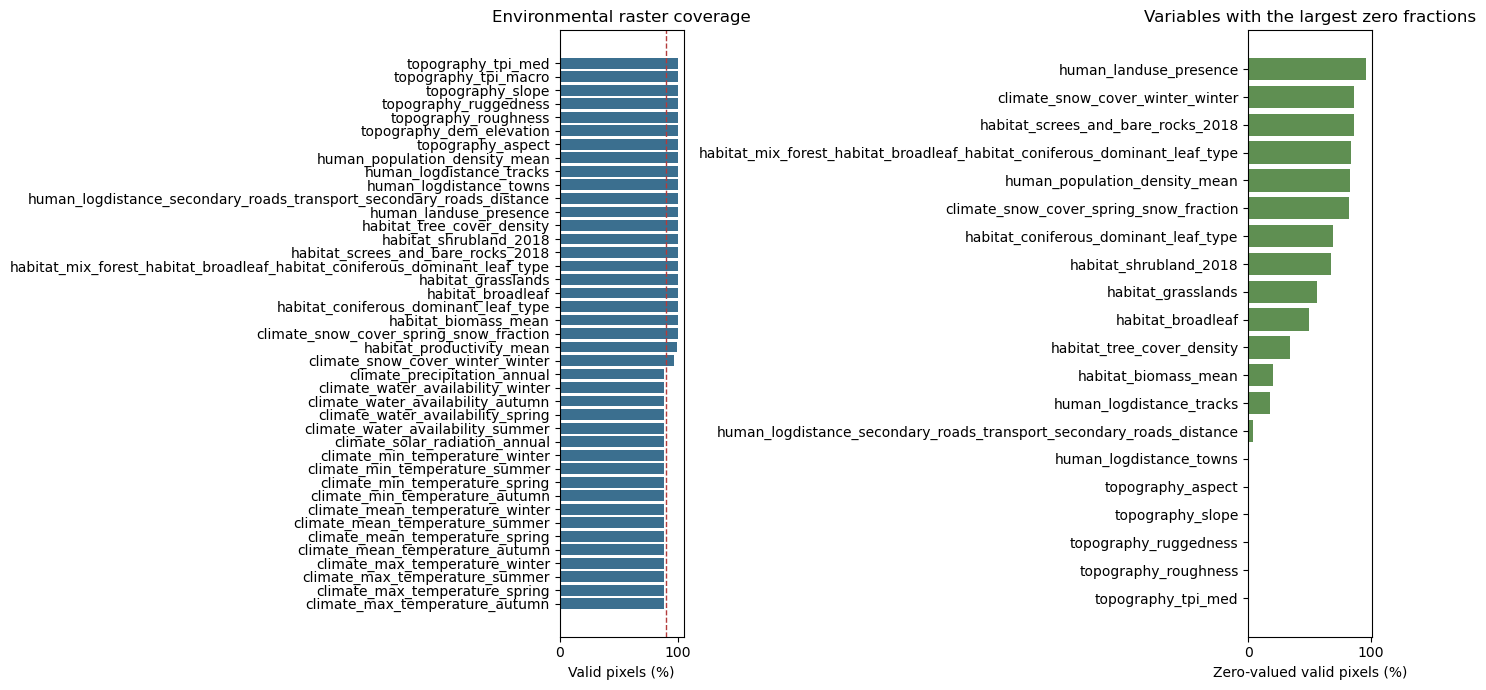

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
coverage = quality.sort_values("valid_pct")
axes[0].barh(coverage["variable"], coverage["valid_pct"], color="#3b6f8f")
axes[0].axvline(90, color="#b33b3b", linestyle="--", linewidth=1)
axes[0].set(xlabel="Valid pixels (%)", title="Environmental raster coverage")

zeroes = quality.sort_values("zero_pct", ascending=False).head(20).sort_values("zero_pct")
axes[1].barh(zeroes["variable"], zeroes["zero_pct"], color="#5f8f52")
axes[1].set(xlabel="Zero-valued valid pixels (%)", title="Variables with the largest zero fractions")

fig.tight_layout()
fig.savefig(PLOT_DIR / "environmental_dataset_quality.png", dpi=250, bbox_inches="tight")
plt.show()

### Interpretation

Incomplete coverage does not automatically imply that a variable is unusable. Coastal boundaries, national source limits, or legitimately undefined surfaces can produce nodata cells. The relevant requirement is that all modelled and predicted cells share complete predictor support. Variables with no variance, extreme zero dominance, or unexpectedly small coverage should be investigated before modelling.

# 3. Biological data preparation

## 3.1 Date parsing, cub classes, and seasonal assignment

The biological sources contain both ISO-style dates and European day-first dates. They are parsed separately to avoid reversing day and month. Each retained observation receives an event month, season, day, and bear-day trajectory group.

GPS data are used for model development. OBS records are cleaned at this stage but remain excluded from training, tuning, calibration, thresholds, and model selection. They are reserved for the final independent audit.

In [10]:
def parse_mixed_datetime(values: pd.Series) -> pd.Series:
    """Parse mixed European and ISO dates without discarding valid records."""
    text = values.astype("string").str.strip()
    parsed = pd.Series(pd.NaT, index=text.index, dtype="datetime64[ns, UTC]")
    iso = text.str.match(r"^\d{4}-\d{2}-\d{2}", na=False)
    if iso.any():
        parsed.loc[iso] = pd.to_datetime(text.loc[iso], errors="coerce", format="mixed", yearfirst=True, utc=True)
    european = ~iso & text.notna()
    if european.any():
        parsed.loc[european] = pd.to_datetime(text.loc[european], errors="coerce", format="mixed", dayfirst=True, utc=True)
    return parsed


def recode_cub_class(values: pd.Series) -> pd.Series:
    return values.astype("string").str.strip().map(CUB_CLASS_MAP).astype("string")


def season_from_month(month: Any) -> str | None:
    if pd.isna(month):
        return None
    return next((season for season, months in SEASON_MONTHS.items() if int(month) in months), None)


def add_event_fields(frame: pd.DataFrame, datetime_col: str) -> pd.DataFrame:
    result = frame.copy()
    result["event_month"] = result[datetime_col].dt.month
    result["event_season"] = result["event_month"].map(season_from_month).astype("string")
    result["event_day"] = result[datetime_col].dt.floor("D")
    bear = result.get("bear_name", pd.Series("unknown", index=result.index)).astype("string")
    result["daily_group"] = bear.fillna("unknown") + "_" + result["event_day"].astype("string")
    return result


def reproject_points(frame: pd.DataFrame, target_crs: str) -> pd.DataFrame:
    transformer = Transformer.from_crs("EPSG:4326", target_crs, always_xy=True)
    x, y = transformer.transform(
        pd.to_numeric(frame["x_long"], errors="coerce").to_numpy(),
        pd.to_numeric(frame["y_lat"], errors="coerce").to_numpy(),
    )
    result = frame.copy()
    result["x_3035"] = x
    result["y_3035"] = y
    return result


def bounds_filter(frame: pd.DataFrame, bounds: dict[str, float]) -> pd.Series:
    lon = pd.to_numeric(frame["x_long"], errors="coerce")
    lat = pd.to_numeric(frame["y_lat"], errors="coerce")
    return lon.between(bounds["xmin"], bounds["xmax"]) & lat.between(bounds["ymin"], bounds["ymax"])


def clean_biological_data(
    gps_path: Path,
    obs_path: Path,
    individuals_path: Path,
    target_crs: str,
    bounds: dict[str, float],
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    gps = pd.read_csv(gps_path)
    obs = pd.read_csv(obs_path)
    individuals = pd.read_csv(individuals_path)
    gps_report: list[dict[str, Any]] = []
    obs_report: list[dict[str, Any]] = []

    def apply(frame: pd.DataFrame, mask: pd.Series, step: str, report: list[dict[str, Any]]) -> pd.DataFrame:
        before = len(frame)
        result = frame.loc[mask].copy()
        report.append({"step": step, "before": before, "after": len(result), "removed": before - len(result)})
        return result

    before = len(gps)
    gps = gps.drop_duplicates("id_obs").copy()
    gps_report.append({"step": "drop duplicated id_obs", "before": before, "after": len(gps), "removed": before - len(gps)})
    gps["datetime_utc"] = parse_mixed_datetime(
        gps["date_gmt"].astype("string").fillna("") + " " + gps["time_gmt"].astype("string").fillna("00:00:00")
    )
    gps["cub_class"] = recode_cub_class(gps["with_cubs_estimated"])
    gps = add_event_fields(gps, "datetime_utc")
    gps["event_year"] = gps["datetime_utc"].dt.year
    gps = apply(gps, gps["cub_class"].notna(), "keep target cub classes", gps_report)
    gps = apply(gps, bounds_filter(gps, bounds), "keep points inside AOI lon/lat bounds", gps_report)
    gps = apply(gps, gps["event_season"].notna(), "keep points with parseable event season", gps_report)
    registry = individuals[["name", "mortality_year", "suposed_desaparition_year"]].copy()
    registry["name_key"] = registry["name"].astype("string").str.lower().str.strip()
    gps["name_key"] = gps["bear_name"].astype("string").str.lower().str.strip()
    gps = gps.merge(registry, on="name_key", how="left", suffixes=("", "_registry"))
    gps["end_year"] = gps[["mortality_year", "suposed_desaparition_year"]].min(axis=1, skipna=True)
    valid_year = ~(gps["end_year"].notna() & gps["event_year"].notna() & (gps["event_year"] > gps["end_year"]))
    gps = apply(gps, valid_year, "remove records after mortality/disappearance year", gps_report)

    before = len(obs)
    obs = obs.drop_duplicates("id_obs").copy()
    obs_report.append({"step": "drop duplicated id_obs", "before": before, "after": len(obs), "removed": before - len(obs)})
    obs["date_parsed"] = parse_mixed_datetime(obs["date"])
    obs["cub_class"] = recode_cub_class(obs["with_cubs_estimated"])
    obs = add_event_fields(obs, "date_parsed")
    obs = apply(obs, obs["cub_class"].notna(), "keep target cub classes", obs_report)
    obs = apply(obs, bounds_filter(obs, bounds), "keep points inside AOI lon/lat bounds", obs_report)
    failed_dates = obs.loc[obs["event_season"].isna(), ["id_obs", "date", "cub_class", "x_long", "y_lat"]].copy()
    obs = apply(obs, obs["event_season"].notna(), "keep points with parseable event season", obs_report)
    return (
        reproject_points(gps, target_crs).reset_index(drop=True),
        reproject_points(obs, target_crs).reset_index(drop=True),
        pd.DataFrame(gps_report),
        pd.DataFrame(obs_report),
        failed_dates,
    )

In [11]:
gps, obs, gps_cleaning, obs_cleaning, failed_obs_dates = clean_biological_data(
    GPS_PATH,
    OBS_PATH,
    INDIVIDUALS_PATH,
    TARGET_CRS,
    BOUNDS_4326,
)

gps_cleaning.to_csv(TABLE_DIR / "gps_cleaning_report.csv", index=False)
obs_cleaning.to_csv(TABLE_DIR / "obs_cleaning_report.csv", index=False)
failed_obs_dates.to_csv(TABLE_DIR / "obs_unparseable_dates.csv", index=False)

display(gps_cleaning)
display(obs_cleaning)
print(f"Clean GPS records before grid treatment: {len(gps):,}")
print(f"Independent OBS records retained: {len(obs):,}")
print(f"Retained OBS records without a season: {obs['event_season'].isna().sum()}")
assert obs["event_season"].notna().all()

,step,before,after,removed
0,drop duplicated id_obs,4629,4629,0
1,keep target cub classes,4629,4629,0
2,keep points inside AOI lon/lat bounds,4629,4629,0
3,keep points with parseable event season,4629,4628,1
4,remove records after mortality/disappearance year,4628,4628,0


,step,before,after,removed
0,drop duplicated id_obs,1962,1962,0
1,keep target cub classes,1962,1190,772
2,keep points inside AOI lon/lat bounds,1190,1167,23
3,keep points with parseable event season,1167,1167,0


Clean GPS records before grid treatment: 4,628
Independent OBS records retained: 1,167
Retained OBS records without a season: 0


,cub_class,event_season,n_records
0,6to12,autumn,1764
1,6to12,spring,4
2,6to12,summer,1139
3,lt6,spring,932
4,lt6,summer,789


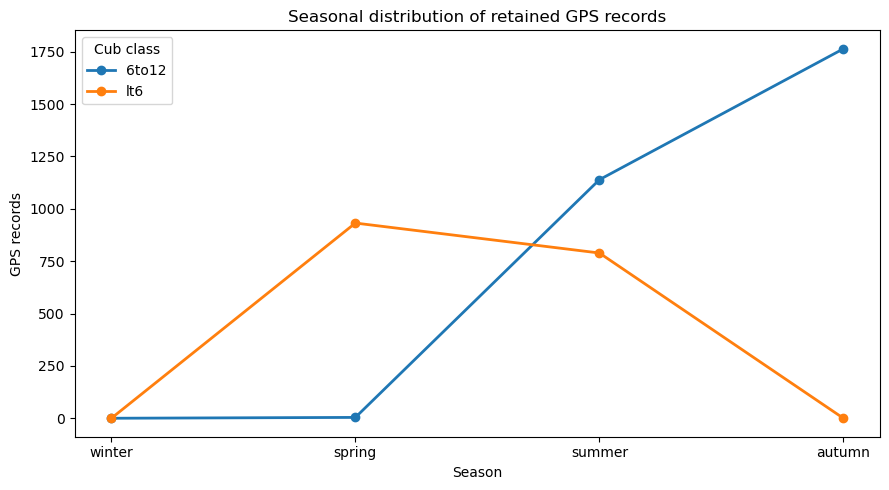

In [12]:
season_counts = (
    gps.groupby(["cub_class", "event_season"], observed=True)
    .size()
    .rename("n_records")
    .reset_index()
)
display(season_counts)

fig, ax = plt.subplots(figsize=(9, 5))
for cub_class, group in season_counts.groupby("cub_class"):
    ordered_counts = (
        group.set_index("event_season")["n_records"]
        .reindex(SEASON_ORDER, fill_value=0)
        .astype(int)
    )
    ax.plot(ordered_counts.index, ordered_counts.to_numpy(), marker="o", linewidth=2, label=cub_class)
ax.set(title="Seasonal distribution of retained GPS records", xlabel="Season", ylabel="GPS records")
ax.legend(title="Cub class")
fig.tight_layout()
fig.savefig(PLOT_DIR / "gps_seasonal_distribution.png", dpi=250)
plt.show()

## 3.2 Official grid assignment and conservative spatial treatment

Coordinates are assigned to the 100 m reference grid. Repeated fixes from the same bear, season, and cell are represented once, preventing heavily sampled locations from dominating solely because of telemetry frequency. A minimum 100 m spacing check is then applied within bear-season groups. No additional temporal thinning is imposed; dependence is addressed through bear-day weighting and grouped bootstrap resampling later in the analysis.

In [13]:
def assign_grid_cells(points: pd.DataFrame, grid_path: Path) -> pd.DataFrame:
    result = points.copy()
    with rasterio.open(grid_path) as grid:
        rows, cols = rowcol(grid.transform, result["x_3035"].to_numpy(), result["y_3035"].to_numpy())
        result["grid_row"] = np.asarray(rows, dtype=int)
        result["grid_col"] = np.asarray(cols, dtype=int)
        inside = result["grid_row"].between(0, grid.height - 1) & result["grid_col"].between(0, grid.width - 1)
    return result.loc[inside].copy()


def spatial_thin_one(frame: pd.DataFrame, min_dist_m: float, iterations: int, seed: int) -> pd.DataFrame:
    if len(frame) <= 1 or min_dist_m <= 0:
        return frame.copy()
    coords = frame[["x_3035", "y_3035"]].to_numpy(dtype=float)
    pairs = cKDTree(coords).query_pairs(r=max(min_dist_m - 1e-9, 0))
    conflicts = [set() for _ in range(len(frame))]
    for left, right in pairs:
        conflicts[left].add(right)
        conflicts[right].add(left)
    rng = np.random.default_rng(seed)
    best = np.ones(len(frame), dtype=bool)
    best_count = -1
    for _ in range(iterations):
        blocked = np.zeros(len(frame), dtype=bool)
        keep = np.zeros(len(frame), dtype=bool)
        for index in rng.permutation(len(frame)):
            if blocked[index]:
                continue
            keep[index] = True
            if conflicts[index]:
                blocked[list(conflicts[index])] = True
        if keep.sum() > best_count:
            best, best_count = keep, int(keep.sum())
    return frame.iloc[np.flatnonzero(best)].copy()


def treat_presences(gps: pd.DataFrame, config: Any) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    dedup_records = []
    thin_records = []
    parts = []
    for cub_class in CUB_CLASSES:
        class_points = gps[gps["cub_class"] == cub_class].copy()
        before = len(class_points)
        class_points = class_points.drop_duplicates(["bear_name", "event_season", "grid_row", "grid_col"])
        dedup_records.append({"cub_class": cub_class, "before": before, "after": len(class_points), "removed": before - len(class_points)})
        for offset, ((bear, season), group) in enumerate(class_points.groupby(["bear_name", "event_season"], dropna=False)):
            treated = spatial_thin_one(group, config.min_thin_distance_m, config.n_thin_iterations, config.random_seed + offset)
            thin_records.append(
                {
                    "cub_class": cub_class,
                    "bear_name": bear,
                    "event_season": season,
                    "before": len(group),
                    "after": len(treated),
                    "removed": len(group) - len(treated),
                }
            )
            parts.append(treated)
    return pd.concat(parts, ignore_index=True), pd.DataFrame(dedup_records), pd.DataFrame(thin_records)

In [14]:
gps = assign_grid_cells(gps, GRID_PATH)
obs = assign_grid_cells(obs, GRID_PATH)
presences, deduplication_report, thinning_report = treat_presences(gps, config)

deduplication_report.to_csv(TABLE_DIR / "gps_grid_cell_deduplication_report.csv", index=False)
thinning_report.to_csv(TABLE_DIR / "gps_spatial_thinning_report.csv", index=False)

presence_summary = (
    presences.groupby(["cub_class", "bear_name", "event_season"], observed=True)
    .agg(
        n_presences=("id_obs", "size"),
        n_days=("daily_group", "nunique"),
        first_observation=("datetime_utc", "min"),
        last_observation=("datetime_utc", "max"),
    )
    .reset_index()
)
presence_summary.to_csv(TABLE_DIR / "individual_presence_summary.csv", index=False)

display(deduplication_report)
display(thinning_report)
display(presence_summary)
print(f"Final treated GPS presences: {len(presences):,}")

,cub_class,before,after,removed
0,lt6,1721,727,994
1,6to12,2907,1116,1791


,cub_class,bear_name,event_season,before,after,removed
0,lt6,Hvala,spring,89,66,23
1,lt6,Hvala,summer,127,97,30
2,lt6,Melba,spring,41,35,6
3,lt6,Melba,summer,25,23,2
4,lt6,Sorita,spring,214,171,43
5,lt6,Sorita,summer,171,110,61
6,lt6,Ziva,spring,38,37,1
7,lt6,Ziva,summer,22,22,0
8,6to12,Hvala,autumn,24,22,2
9,6to12,Hvala,spring,3,3,0


,cub_class,bear_name,event_season,n_presences,n_days,first_observation,last_observation
0,6to12,Hvala,autumn,22,21,2007-09-20 08:45:00+00:00,2009-11-03 00:00:00+00:00
1,6to12,Hvala,spring,3,3,2009-04-29 00:00:00+00:00,2009-05-30 00:00:00+00:00
2,6to12,Hvala,summer,53,42,2007-07-01 00:01:00+00:00,2009-08-26 00:00:00+00:00
3,6to12,Melba,autumn,5,5,1997-09-02 07:00:00+00:00,1997-09-27 09:27:00+00:00
4,6to12,Melba,summer,45,44,1997-07-01 07:01:00+00:00,1997-08-31 09:30:00+00:00
5,6to12,Sorita,autumn,225,69,2019-09-01 01:00:00+00:00,2019-11-16 17:20:00+00:00
6,6to12,Sorita,summer,389,61,2019-07-01 06:00:00+00:00,2019-08-31 21:01:00+00:00
7,6to12,Ziva,autumn,72,72,1997-09-02 09:30:00+00:00,1997-11-23 09:50:00+00:00
8,6to12,Ziva,summer,52,52,1997-07-01 07:00:00+00:00,1997-08-31 07:00:00+00:00
9,lt6,Hvala,spring,66,22,2007-05-01 03:01:00+00:00,2007-05-29 18:01:00+00:00


Final treated GPS presences: 1,427


## 3.3 Spatial distribution of occupied grid cells

The following map shows the spatial extent represented by each monitored bear. It is an important diagnostic because model transfer is difficult when individuals occupy partially distinct geographic and environmental regions.

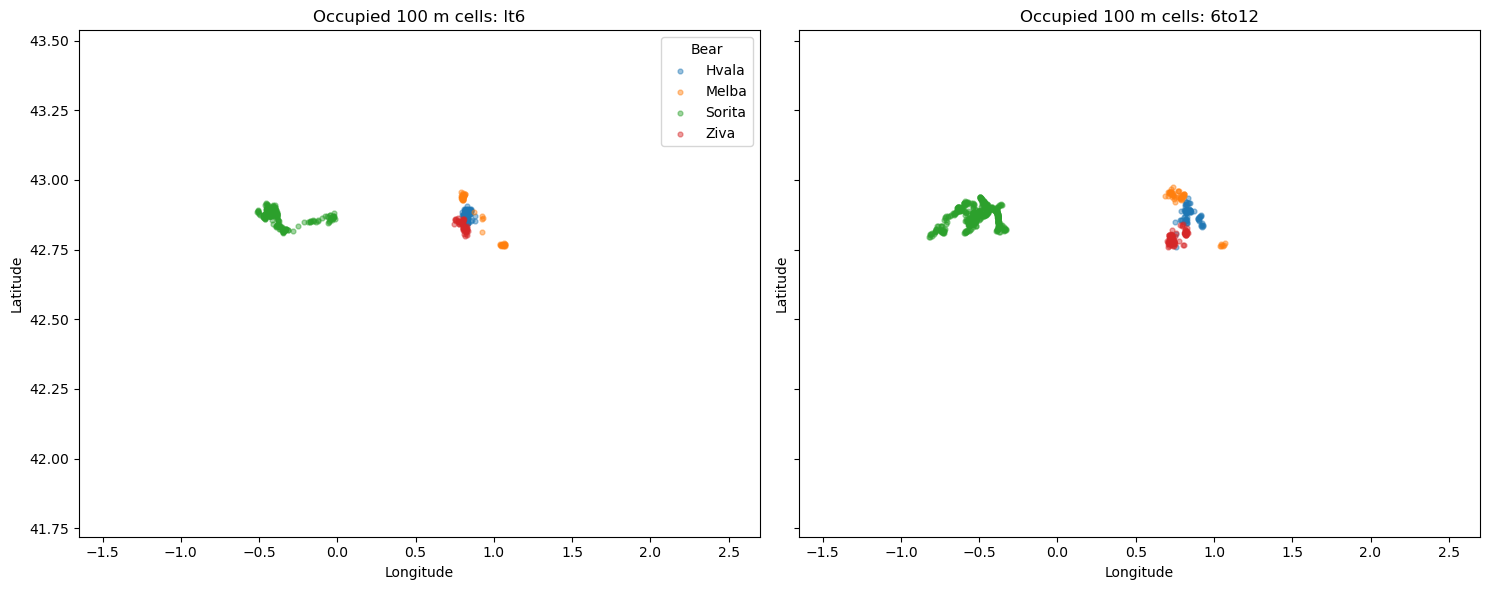

In [15]:
transformer_to_4326 = Transformer.from_crs(TARGET_CRS, "EPSG:4326", always_xy=True)
plot_points = presences.copy()
plot_points["longitude"], plot_points["latitude"] = transformer_to_4326.transform(
    plot_points["x_3035"].to_numpy(), plot_points["y_3035"].to_numpy()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)
palette = dict(zip(sorted(plot_points["bear_name"].unique()), plt.get_cmap("tab10").colors))
for ax, cub_class in zip(axes, CUB_CLASSES):
    subset = plot_points[plot_points["cub_class"] == cub_class]
    for bear, group in subset.groupby("bear_name"):
        ax.scatter(group["longitude"], group["latitude"], s=12, alpha=0.45, color=palette[bear], label=bear)
    ax.set_xlim(BOUNDS_4326["xmin"], BOUNDS_4326["xmax"])
    ax.set_ylim(BOUNDS_4326["ymin"], BOUNDS_4326["ymax"])
    ax.set(title=f"Occupied 100 m cells: {cub_class}", xlabel="Longitude", ylabel="Latitude")
axes[0].legend(title="Bear", loc="best")
fig.tight_layout()
fig.savefig(PLOT_DIR / "occupied_grid_cells_by_bear_epsg4326.png", dpi=250)
plt.show()

# 4. Spatial domains and background sampling

## 4.1 Full regional domain and locally accessible domain

Presence-background models compare observed locations with available environmental conditions. Consequently, the background domain is part of the ecological question rather than a neutral technical choice.

The full domain represents the complete configured Pyrenean AOI. The local domain is formed from separate individual movement hulls buffered by 25 km and clipped to the AOI. Individual hulls are buffered before union so that geographically distinct ranges remain separate unless their buffers genuinely meet. Sensitivity statistics for 20, 25, and 30 km quantify how area and connectivity change with the buffer distance.

In [16]:
def load_custom_geometry(path: Path, target_crs: str):
    import geopandas as gpd

    frame = gpd.read_file(path)
    if frame.empty:
        raise ValueError(f"Custom local domain is empty: {path}")
    if frame.crs is None:
        raise ValueError("Custom local domain must declare its CRS.")
    return frame.to_crs(target_crs).geometry.union_all()


def build_domain_geometries(
    gps: pd.DataFrame,
    grid_path: Path,
    target_crs: str,
    config: Any,
) -> tuple[dict[str, Any], pd.DataFrame]:
    with rasterio.open(grid_path) as grid:
        full = box(*grid.bounds)
    records = []
    sensitivity: dict[float, Any] = {}
    for buffer_km in config.local_buffer_sensitivity_km:
        geometry = unary_union(
            [
                MultiPoint(group[["x_3035", "y_3035"]].to_numpy()).convex_hull.buffer(buffer_km * 1_000)
                for _, group in gps.groupby("bear_name")
            ]
        ).intersection(full)
        sensitivity[float(buffer_km)] = geometry
        records.append(
            {
                "buffer_km": float(buffer_km),
                "area_km2": geometry.area / 1_000_000,
                "n_components": len(geometry.geoms) if hasattr(geometry, "geoms") else 1,
                "contains_all_gps": bool(all(geometry.covers(Point(x, y)) for x, y in gps[["x_3035", "y_3035"]].to_numpy())),
            }
        )
    if config.custom_local_domain_path:
        local = load_custom_geometry(Path(config.custom_local_domain_path), target_crs).intersection(full)
        local_source = "custom"
    else:
        local = sensitivity[float(config.local_buffer_km)]
        local_source = "separate_bear_hulls"
    if not all(local.covers(Point(x, y)) for x, y in gps[["x_3035", "y_3035"]].to_numpy()):
        raise ValueError("The selected local domain does not contain every treated GPS point.")
    table = pd.DataFrame(records)
    table["selected"] = np.isclose(table["buffer_km"], config.local_buffer_km) & (local_source != "custom")
    table["source"] = local_source
    return {"full_aoi": full, "local_domain": local}, table


def domain_mask(geometry: Any, grid_path: Path) -> np.ndarray:
    with rasterio.open(grid_path) as grid:
        return geometry_mask([mapping(geometry)], out_shape=grid.shape, transform=grid.transform, invert=True)

In [17]:
domain_geometries, domain_sensitivity = build_domain_geometries(
    presences,
    GRID_PATH,
    TARGET_CRS,
    config,
)
domain_masks = {
    name: domain_mask(geometry, GRID_PATH) & common_mask
    for name, geometry in domain_geometries.items()
}

domain_summary = pd.DataFrame(
    [
        {
            "domain": name,
            "geometric_area_km2": geometry.area / 1_000_000,
            "complete_predictor_area_km2": domain_masks[name].sum() * 0.01,
            "n_components": len(geometry.geoms) if hasattr(geometry, "geoms") else 1,
        }
        for name, geometry in domain_geometries.items()
    ]
)

domain_sensitivity.to_csv(TABLE_DIR / "local_domain_sensitivity.csv", index=False)
domain_summary.to_csv(TABLE_DIR / "modelling_domain_summary.csv", index=False)
display(domain_summary)
display(domain_sensitivity)

selected_local = domain_geometries["local_domain"]
assert all(selected_local.covers(Point(x, y)) for x, y in presences[["x_3035", "y_3035"]].to_numpy())
if CUSTOM_LOCAL_DOMAIN_PATH is None and np.isclose(LOCAL_BUFFER_KM, 25):
    assert len(selected_local.geoms) == 2

,domain,geometric_area_km2,complete_predictor_area_km2,n_components
0,full_aoi,54560.000000,46795.90,1
1,local_domain,10775.934906,10377.98,2


,buffer_km,area_km2,n_components,contains_all_gps,selected,source
0,20.0,8198.001143,2,True,False,separate_bear_hulls
1,25.0,10775.934906,2,True,True,separate_bear_hulls
2,30.0,13640.579868,1,True,False,separate_bear_hulls


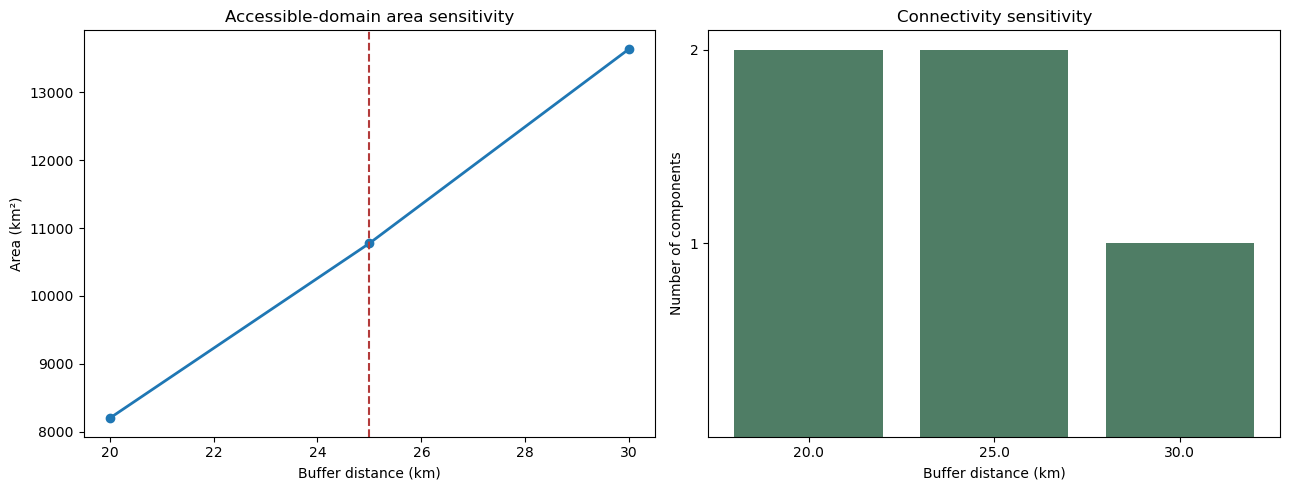

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(domain_sensitivity["buffer_km"], domain_sensitivity["area_km2"], marker="o", linewidth=2)
axes[0].axvline(LOCAL_BUFFER_KM, color="#b33b3b", linestyle="--")
axes[0].set(title="Accessible-domain area sensitivity", xlabel="Buffer distance (km)", ylabel="Area (km²)")

axes[1].bar(domain_sensitivity["buffer_km"].astype(str), domain_sensitivity["n_components"], color="#4f7d65")
axes[1].set(title="Connectivity sensitivity", xlabel="Buffer distance (km)", ylabel="Number of components")
axes[1].set_yticks(sorted(domain_sensitivity["n_components"].unique()))
fig.tight_layout()
fig.savefig(PLOT_DIR / "local_domain_buffer_sensitivity.png", dpi=250)
plt.show()

## 4.2 Independent training and evaluation background pools

Four deterministic pools are sampled before fitting any model: local evaluation, full-AOI evaluation, local training, and full-AOI training. Their grid-cell identifiers must be mutually exclusive. Every candidate is then evaluated on exactly the same cells within each scenario, making comparisons among domains and algorithms fair.

In [19]:
def sample_background_cells(
    valid_mask: np.ndarray,
    n: int,
    seed: int,
    excluded_ids: set[int] | None = None,
) -> pd.DataFrame:
    rows, cols = np.where(valid_mask)
    with rasterio.open(sample_background_cells.grid_path) as grid:  # type: ignore[attr-defined]
        width = grid.width
        ids = rows.astype(np.int64) * width + cols.astype(np.int64)
        if excluded_ids:
            keep = ~np.isin(ids, np.fromiter(excluded_ids, dtype=np.int64))
            rows, cols, ids = rows[keep], cols[keep], ids[keep]
        if n > len(rows):
            raise ValueError(f"Requested {n} unique background cells from only {len(rows)} available cells.")
        chosen = np.random.default_rng(seed).choice(len(rows), n, replace=False)
        selected_rows, selected_cols, selected_ids = rows[chosen], cols[chosen], ids[chosen]
        xs, ys = xy(grid.transform, selected_rows, selected_cols, offset="center")
    return pd.DataFrame(
        {
            "cell_id": selected_ids,
            "x_3035": np.asarray(xs, dtype=float),
            "y_3035": np.asarray(ys, dtype=float),
            "grid_row": selected_rows,
            "grid_col": selected_cols,
            "label": 0,
            "source": "background",
            "bear_name": "background",
        }
    )


def create_background_pools(
    masks: dict[str, np.ndarray],
    grid_path: Path,
    config: Any,
) -> dict[str, pd.DataFrame]:
    sample_background_cells.grid_path = grid_path  # type: ignore[attr-defined]
    local_test = sample_background_cells(masks["local_domain"], config.n_background_test, config.random_seed + 100)
    excluded = set(local_test["cell_id"].astype(int))
    full_test = sample_background_cells(masks["full_aoi"], config.n_background_test, config.random_seed + 200, excluded)
    excluded.update(full_test["cell_id"].astype(int))
    local_train = sample_background_cells(masks["local_domain"], config.n_background_train, config.random_seed + 300, excluded)
    excluded.update(local_train["cell_id"].astype(int))
    full_train = sample_background_cells(masks["full_aoi"], config.n_background_train, config.random_seed + 400, excluded)
    pools = {
        "local_test": local_test,
        "full_test": full_test,
        "local_train": local_train,
        "full_train": full_train,
    }
    test_ids = set(local_test.cell_id) | set(full_test.cell_id)
    train_ids = set(local_train.cell_id) | set(full_train.cell_id)
    if test_ids & train_ids:
        raise AssertionError("Training and evaluation background pools overlap.")
    return pools

In [20]:
background_pools = create_background_pools(domain_masks, GRID_PATH, config)
for pool_name, pool in background_pools.items():
    pool.to_csv(INTERMEDIATE_DIR / f"background_{pool_name}.csv", index=False)

background_summary = pd.DataFrame(
    [{"pool": name, "n_cells": len(pool), "unique_cells": pool["cell_id"].nunique()} for name, pool in background_pools.items()]
)
display(background_summary)

pool_ids = {name: set(pool["cell_id"]) for name, pool in background_pools.items()}
for left_name, left_ids in pool_ids.items():
    for right_name, right_ids in pool_ids.items():
        if left_name < right_name:
            assert left_ids.isdisjoint(right_ids), f"Background overlap between {left_name} and {right_name}"

,pool,n_cells,unique_cells
0,local_test,2000,2000
1,full_test,2000,2000
2,local_train,10000,10000
3,full_train,10000,10000


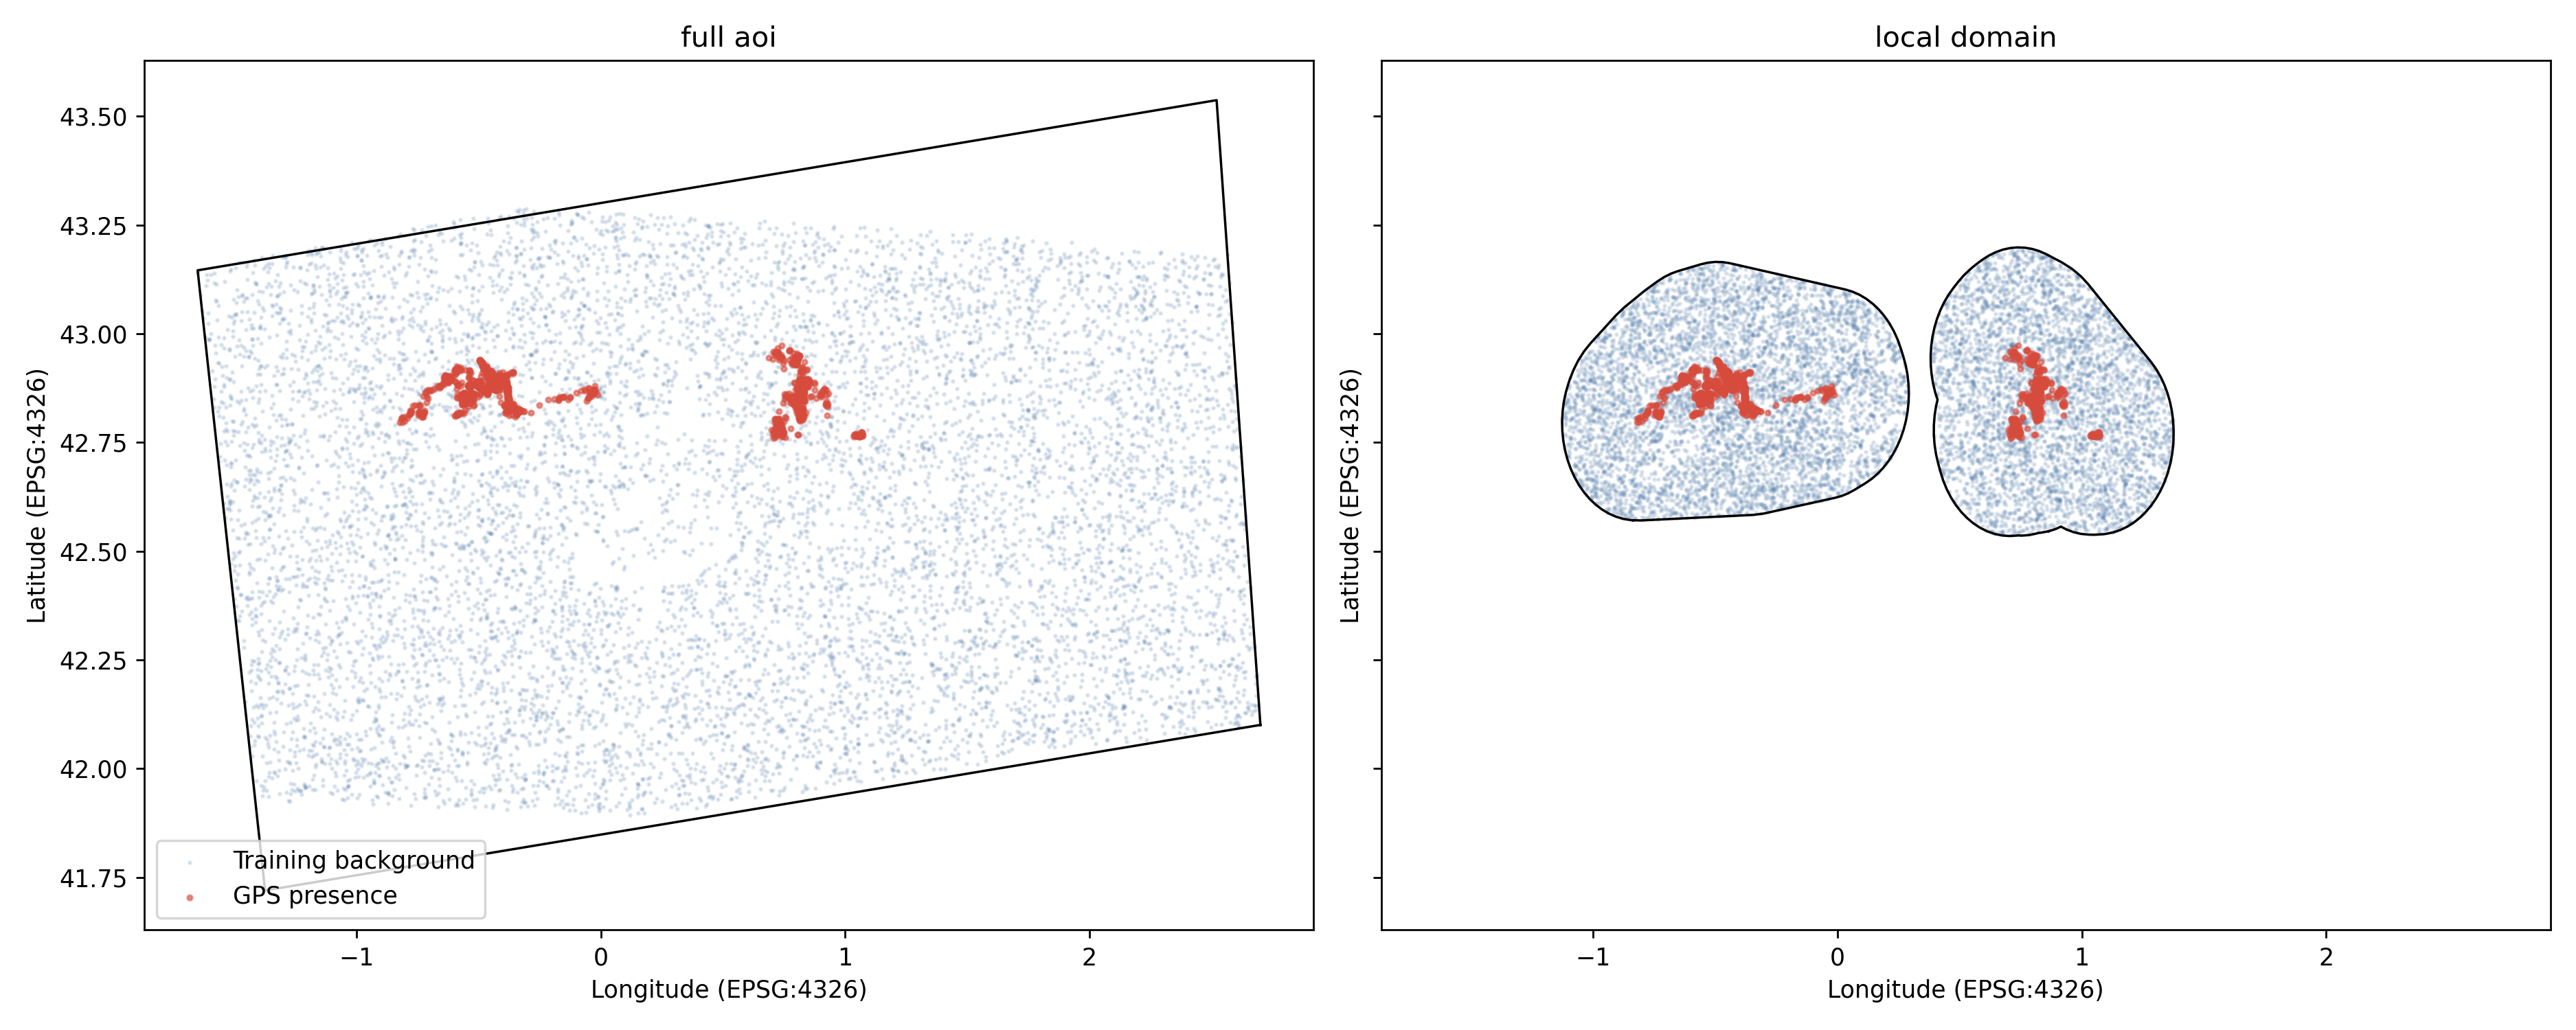

In [21]:
def plot_domains_4326(
    presences: pd.DataFrame,
    pools: dict[str, pd.DataFrame],
    geometries: dict[str, Any],
    source_crs: str,
    output_path: Path,
):
    transformer = Transformer.from_crs(source_crs, "EPSG:4326", always_xy=True)
    to_lonlat = lambda x, y, z=None: transformer.transform(x, y)
    fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)
    for ax, domain, pool_name in zip(axes, ("full_aoi", "local_domain"), ("full_train", "local_train")):
        geometry = transform_geometry(to_lonlat, geometries[domain])
        pieces = [geometry] if geometry.geom_type == "Polygon" else list(geometry.geoms)
        for piece in pieces:
            x, y = piece.exterior.xy
            ax.plot(x, y, color="black", linewidth=1)
        background = pools[pool_name]
        lon, lat = transformer.transform(background["x_3035"].to_numpy(), background["y_3035"].to_numpy())
        ax.scatter(lon, lat, s=1, alpha=0.15, color="#4c78a8", label="Training background")
        presence_lon, presence_lat = transformer.transform(presences["x_3035"].to_numpy(), presences["y_3035"].to_numpy())
        ax.scatter(presence_lon, presence_lat, s=4, alpha=0.55, color="#d64b3c", label="GPS presence")
        ax.set(title=domain.replace("_", " "), xlabel="Longitude (EPSG:4326)", ylabel="Latitude (EPSG:4326)")
    axes[0].legend(loc="lower left")
    fig.tight_layout()
    fig.savefig(output_path, dpi=250)
    plt.close(fig)


plot_domains_4326(
    presences,
    background_pools,
    domain_geometries,
    TARGET_CRS,
    PLOT_DIR / "modelling_domains_backgrounds_epsg4326.png",
)
display(Image(filename=str(PLOT_DIR / "modelling_domains_backgrounds_epsg4326.png")))

### Interpretation

A regional background includes many environments that are clearly unsuitable and can therefore make discrimination comparatively easy. A local background contains more environmentally similar alternatives and asks a harder question: which habitats are selected within the currently accessible landscape? Lower local-domain performance is not necessarily a defect; it can reflect a more demanding and ecologically focused comparison. The two models must therefore be judged on shared evaluation sets rather than on their own training domains.

# 5. Seasonal predictor extraction and model-table diagnostics

## 5.1 Observation-specific seasonal predictors

Static and annual variables are sampled identically for every point. Seasonal variables are selected according to each GPS or OBS date. This preserves one model per cub class while allowing a spring record to receive spring conditions and a summer record to receive summer conditions. For snow cover, summer and autumn values without a corresponding source layer are represented as zero snow.

In [22]:
def sample_raster(path: Path, coords: list[tuple[float, float]]) -> np.ndarray:
    with rasterio.open(path) as src:
        values = np.array([item[0] for item in src.sample(coords)], dtype=float)
        if src.nodata is not None:
            values[np.isclose(values, src.nodata)] = np.nan
    values[~np.isfinite(values)] = np.nan
    return values


def extract_features(points: pd.DataFrame, inventory: pd.DataFrame) -> pd.DataFrame:
    coords = list(zip(points["x_3035"].astype(float), points["y_3035"].astype(float)))
    values: dict[str, np.ndarray] = {}
    for item in inventory[inventory["temporal_role"].isin(["static", "annual"])].itertuples(index=False):
        values.setdefault(item.model_variable, sample_raster(Path(item.path), coords))
    for variable, group in inventory[inventory["temporal_role"] == "seasonal"].groupby("model_variable"):
        output = np.full(len(points), np.nan)
        for item in group.itertuples(index=False):
            mask = points["event_season"].astype("string").eq(str(item.temporal_dimension)).to_numpy()
            if mask.any():
                indexes = np.flatnonzero(mask)
                output[indexes] = sample_raster(Path(item.path), [coords[index] for index in indexes])
        if "snow_cover" in variable:
            no_snow = points["event_season"].isin(["summer", "autumn"]).to_numpy()
            output[np.isnan(output) & no_snow] = 0.0
        values[variable] = output
    result = pd.DataFrame(values, index=points.index)
    if "topography_aspect" in result:
        radians = np.deg2rad(pd.to_numeric(result.pop("topography_aspect"), errors="coerce"))
        result["topography_aspect_sin"] = np.sin(radians)
        result["topography_aspect_cos"] = np.cos(radians)
    return result


def assign_background_seasons(background: pd.DataFrame, presences: pd.DataFrame, seed: int) -> pd.DataFrame:
    seasons = presences["event_season"].dropna().astype(str).to_numpy()
    if not len(seasons):
        raise ValueError("Cannot assign background seasons without dated presences.")
    result = background.copy()
    result["event_season"] = np.random.default_rng(seed).choice(seasons, len(result), replace=True)
    result["daily_group"] = "background"
    return result

## 5.2 Equal influence across bears and observed days

Telemetry effort differs among individuals and days. To prevent the most intensively sampled bear or trajectory from dominating the likelihood, total presence influence is divided equally among bears, then among observed days within each bear, and finally among fixes within a day. Presence and background each receive half of the total model weight.

Weights are rescaled to the number of training rows. This leaves relative ecological influence unchanged while maintaining numerically appropriate Hessian magnitudes for XGBoost.

In [23]:
def presence_weights(presences: pd.DataFrame) -> np.ndarray:
    """Give equal total influence to bears and to observed days within each bear."""
    weights = pd.Series(0.0, index=presences.index)
    bears = list(presences["bear_name"].dropna().unique())
    for bear in bears:
        bear_rows = presences[presences["bear_name"] == bear]
        days = list(bear_rows["daily_group"].dropna().unique())
        for day in days:
            indexes = bear_rows.index[bear_rows["daily_group"] == day]
            weights.loc[indexes] = 1.0 / (len(bears) * len(days) * len(indexes))
    return weights.to_numpy()


def model_sample_weights(table: pd.DataFrame) -> np.ndarray:
    weights = np.zeros(len(table), dtype=float)
    positive = table["label"].to_numpy() == 1
    if positive.any():
        weights[positive] = presence_weights(table.loc[positive])
    if (~positive).any():
        weights[~positive] = 1.0 / (~positive).sum()
    weights[positive] *= 0.5 / max(weights[positive].sum(), 1e-12)
    weights[~positive] *= 0.5 / max(weights[~positive].sum(), 1e-12)
    # Preserve relative ecological weights while keeping XGBoost Hessian scales
    # comparable to ordinary per-row weights.
    return weights * len(table)


def build_model_data(
    presences: pd.DataFrame,
    pools: dict[str, pd.DataFrame],
    inventory: pd.DataFrame,
) -> tuple[dict[str, dict[str, Any]], list[str]]:
    all_variables = set(inventory["model_variable"])
    full_features = sorted((all_variables - {"topography_aspect"}) | {"topography_aspect_sin", "topography_aspect_cos"})
    reduced_features = [name for name in full_features if name not in REDUCED_FEATURE_EXCLUSIONS]
    result: dict[str, dict[str, Any]] = {}
    for cub_class in CUB_CLASSES:
        class_pres = presences[presences["cub_class"] == cub_class].copy()
        class_pres["point_id"] = class_pres["id_obs"].astype("string")
        class_pres["label"] = 1
        class_pres["source"] = "gps"
        presence_columns = [
            "point_id", "x_3035", "y_3035", "grid_row", "grid_col", "source", "label",
            "bear_name", "event_season", "daily_group",
        ]
        presence_table = class_pres[presence_columns].reset_index(drop=True)
        presence_features = extract_features(presence_table, inventory)
        presence_table = pd.concat([presence_table, presence_features], axis=1)
        class_data: dict[str, Any] = {"presences": presence_table}
        pool_offsets = {"local_test": 100, "full_test": 200, "local_train": 300, "full_train": 400}
        class_offset = 0 if cub_class == "lt6" else 1_000
        for pool_name, pool in pools.items():
            seasonal = assign_background_seasons(pool, class_pres, 10_000 + class_offset + pool_offsets[pool_name])
            seasonal["point_id"] = pool_name + "_" + seasonal["cell_id"].astype(str)
            columns = [
                "point_id", "cell_id", "x_3035", "y_3035", "grid_row", "grid_col", "source",
                "label", "bear_name", "event_season", "daily_group",
            ]
            table = seasonal[columns].reset_index(drop=True)
            table = pd.concat([table, extract_features(table, inventory)], axis=1)
            class_data[pool_name] = table
        for key, table in class_data.items():
            missing = table[reduced_features].isna().any(axis=1)
            if missing.any():
                class_data[key] = table.loc[~missing].reset_index(drop=True)
        result[cub_class] = class_data
    return result, reduced_features

In [24]:
model_data, feature_cols = build_model_data(presences, background_pools, inventory)

for cub_class, data in model_data.items():
    data["presences"].to_csv(INTERMEDIATE_DIR / f"presences_{cub_class}.csv", index=False)
    for pool_name in background_pools:
        data[pool_name].to_csv(INTERMEDIATE_DIR / f"features_{cub_class}_{pool_name}.csv", index=False)

feature_set = pd.DataFrame(
    {
        "feature": sorted(set(feature_cols) | REDUCED_FEATURE_EXCLUSIONS),
        "included_in_reduced_set": [
            feature in feature_cols for feature in sorted(set(feature_cols) | REDUCED_FEATURE_EXCLUSIONS)
        ],
    }
)
feature_set.to_csv(TABLE_DIR / "model_feature_sets.csv", index=False)
display(feature_set)
print(f"Predictors used by the models: {len(feature_cols)}")

,feature,included_in_reduced_set
0,climate_max_temperature,False
1,climate_mean_temperature,True
2,climate_min_temperature,False
3,climate_precipitation_annual,True
4,climate_snow_cover,True
5,climate_solar_radiation_annual,True
6,climate_water_availability,True
7,habitat_biomass_mean,True
8,habitat_broadleaf,True
9,habitat_coniferous_dominant_leaf_type,True


Predictors used by the models: 24


## 5.3 Model-table dimensions, missingness, and class composition

Rows lacking any reduced-set predictor are removed after extraction. The following diagnostics make these losses explicit and verify the number of presences and background cells available to each class and domain.

In [25]:
table_records = []
for cub_class, data in model_data.items():
    for table_name, table in data.items():
        table_records.append(
            {
                "cub_class": cub_class,
                "table": table_name,
                "rows": len(table),
                "presence_rows": int(table["label"].sum()),
                "background_rows": int((table["label"] == 0).sum()),
                "missing_predictor_cells": int(table[feature_cols].isna().sum().sum()),
            }
        )
model_table_summary = pd.DataFrame(table_records)
model_table_summary.to_csv(TABLE_DIR / "model_table_summary.csv", index=False)
display(model_table_summary)

weight_checks = []
for cub_class, data in model_data.items():
    table = pd.concat([data["presences"], data["full_train"]], ignore_index=True)
    weights = model_sample_weights(table)
    for bear in sorted(data["presences"]["bear_name"].unique()):
        mask = table["bear_name"].eq(bear).to_numpy()
        weight_checks.append({"cub_class": cub_class, "bear": bear, "total_weight": weights[mask].sum()})
display(pd.DataFrame(weight_checks))

,cub_class,table,rows,presence_rows,background_rows,missing_predictor_cells
0,lt6,presences,561,561,0,0
1,lt6,local_test,2000,0,2000,0
2,lt6,full_test,2000,0,2000,0
3,lt6,local_train,10000,0,10000,0
4,lt6,full_train,10000,0,10000,0
5,6to12,presences,866,866,0,0
6,6to12,local_test,2000,0,2000,0
7,6to12,full_test,2000,0,2000,0
8,6to12,local_train,10000,0,10000,0
9,6to12,full_train,10000,0,10000,0


,cub_class,bear,total_weight
0,lt6,Hvala,1320.125
1,lt6,Melba,1320.125
2,lt6,Sorita,1320.125
3,lt6,Ziva,1320.125
4,6to12,Hvala,1358.250
5,6to12,Melba,1358.250
6,6to12,Sorita,1358.250
7,6to12,Ziva,1358.250


## 5.4 Predictor distributions and correlation structure

Tree models can accommodate nonlinear relations and correlated predictors, but strong redundancy can make importance measures unstable and obscure ecological interpretation. Correlation is therefore inspected as a diagnostic rather than used as an automatic deletion rule. The reduced feature set excludes a small number of known redundant variables while retaining ecologically distinct predictors.

In [26]:
presence_predictor_summary = []
correlation_records = []
for cub_class, data in model_data.items():
    table = data["presences"]
    summary = table[feature_cols].describe(percentiles=[0.05, 0.5, 0.95]).T.reset_index(names="feature")
    summary.insert(0, "cub_class", cub_class)
    presence_predictor_summary.append(summary)

    correlation = table[feature_cols].corr(method="spearman")
    for left_index, left in enumerate(feature_cols):
        for right in feature_cols[left_index + 1 :]:
            value = correlation.loc[left, right]
            if np.isfinite(value) and abs(value) >= 0.80:
                correlation_records.append(
                    {"cub_class": cub_class, "feature_1": left, "feature_2": right, "spearman_r": value}
                )

presence_predictor_summary = pd.concat(presence_predictor_summary, ignore_index=True)
high_correlations = pd.DataFrame(correlation_records)
presence_predictor_summary.to_csv(TABLE_DIR / "presence_predictor_summary.csv", index=False)
high_correlations.to_csv(TABLE_DIR / "high_correlation_pairs.csv", index=False)
display(presence_predictor_summary.head(30))
display(high_correlations.sort_values("spearman_r", key=abs, ascending=False).head(30))

,cub_class,feature,count,mean,std,min,5%,50%,95%,max
0,lt6,climate_mean_temperature,561.0,8.328989,4.381627,-1.095108,2.128979,7.871543,14.143909,17.977272
1,lt6,climate_precipitation_annual,561.0,1590.865969,229.212981,1063.010010,1222.997314,1547.437256,1909.758789,2108.317627
2,lt6,climate_snow_cover,561.0,4.861795,10.463048,0.000000,0.000000,0.000000,26.533333,80.941818
3,lt6,climate_solar_radiation_annual,561.0,1717.640631,389.331998,760.549561,1036.143555,1733.216919,2246.830322,2287.499512
4,lt6,climate_water_availability,561.0,70.596881,42.869740,-19.451487,14.688925,71.542778,134.900635,160.808517
5,lt6,habitat_biomass_mean,561.0,93.589022,82.044680,0.000000,0.000000,87.669754,226.390823,255.624298
6,lt6,habitat_broadleaf,561.0,0.301640,0.380611,0.000000,0.000000,0.070000,1.000000,1.000000
7,lt6,habitat_coniferous_dominant_leaf_type,561.0,0.241426,0.360135,0.000000,0.000000,0.000000,1.000000,1.000000
8,lt6,habitat_grasslands,561.0,0.365989,0.407277,0.000000,0.000000,0.130000,1.000000,1.000000
9,lt6,habitat_mix_forest_habitat_broadleaf_habitat_c...,561.0,0.100463,0.217982,0.000000,0.000000,0.000000,0.640000,1.000000


,cub_class,feature_1,feature_2,spearman_r
0,lt6,climate_mean_temperature,climate_water_availability,-0.962749
2,6to12,climate_mean_temperature,climate_water_availability,-0.912492
1,lt6,climate_solar_radiation_annual,topography_aspect_cos,-0.905423
3,6to12,climate_solar_radiation_annual,topography_aspect_cos,-0.903772


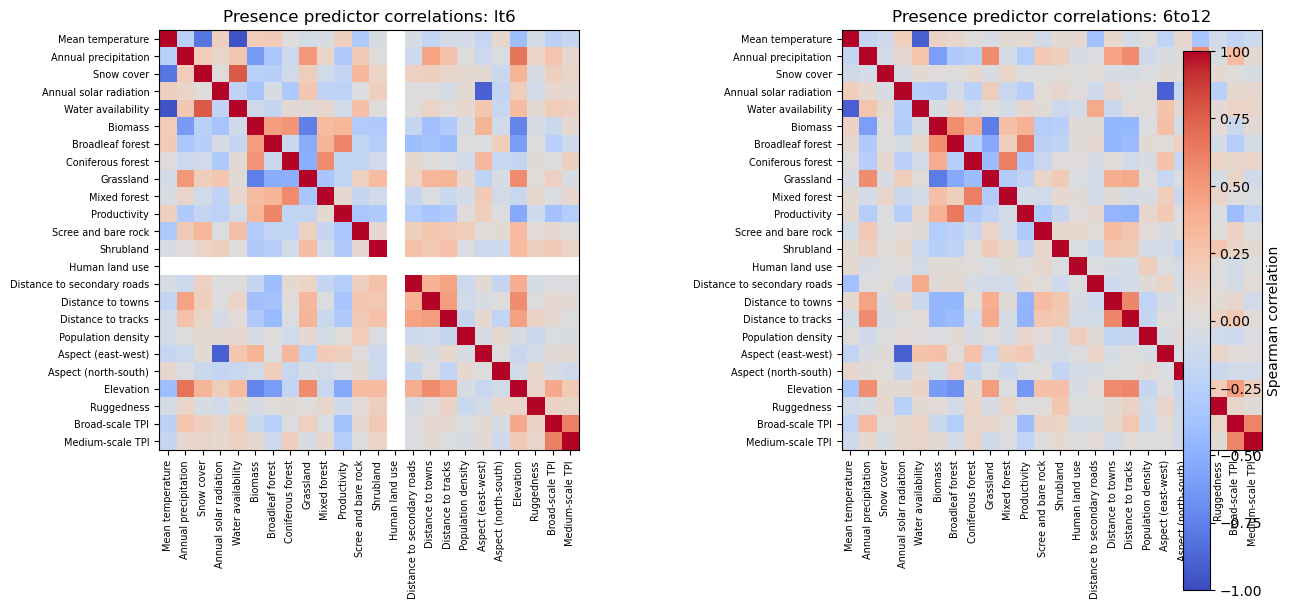

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, cub_class in zip(axes, CUB_CLASSES):
    correlation = model_data[cub_class]["presences"][feature_cols].corr(method="spearman")
    image = ax.imshow(correlation, vmin=-1, vmax=1, cmap="coolwarm")
    ax.set_title(f"Presence predictor correlations: {cub_class}")
    ax.set_xticks(range(len(feature_cols)), [SHORT_FEATURE_LABELS.get(f, f) for f in feature_cols], rotation=90, fontsize=7)
    ax.set_yticks(range(len(feature_cols)), [SHORT_FEATURE_LABELS.get(f, f) for f in feature_cols], fontsize=7)
fig.colorbar(image, ax=axes, fraction=0.025, pad=0.02, label="Spearman correlation")
fig.subplots_adjust(left=0.17, right=0.93, bottom=0.31, top=0.91, wspace=0.28)
fig.savefig(PLOT_DIR / "presence_predictor_correlations.png", dpi=250)
plt.show()

# 6. Evaluation criteria and model algorithms

## 6.1 Performance metrics

No single metric fully describes a habitat suitability model. The analysis reports complementary measures:

- **ROC AUC** assesses ranking across thresholds. A value of 0.5 represents random ranking and 1.0 perfect ranking.
- **Precision-recall AUC** emphasizes correct identification of presences and is sensitive to false positives.
- **Continuous Boyce index** tests whether higher predicted suitability contains presences more frequently than expected. Positive values are desirable; negative values indicate an inverse or unstable suitability relationship.
- **Brier score** measures squared prediction error; lower values are better.
- **Log loss** penalizes confident errors; lower values are better.
- **True Skill Statistic** combines sensitivity and specificity at the best ROC threshold; values above zero indicate useful discrimination.

Evaluation weights assign equal total contribution to held-out presences and evaluation background. This prevents the chosen number of background samples from determining the metrics.

In [28]:
DEFAULT_RF_PARAMS = {
    "n_estimators": 500,
    "max_depth": None,
    "max_features": "sqrt",
    "min_samples_leaf": 5,
    "n_jobs": -1,
    "random_state": 42,
}
DEFAULT_XGB_PARAMS = {
    "n_estimators": 500,
    "max_depth": 3,
    "learning_rate": 0.03,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 3,
    "reg_alpha": 0.01,
    "reg_lambda": 1.0,
    "tree_method": "hist",
    "eval_metric": "auc",
    "random_state": 42,
    "n_jobs": -1,
}
RF_PARAM_DIST = {
    "n_estimators": [300, 500, 800, 1_000],
    "max_depth": [None, 10, 20, 30],
    "max_features": ["sqrt", "log2", 0.3, 0.5],
    "min_samples_leaf": [2, 5, 10, 20],
}


def boyce_index(scores: Iterable[float], presence_mask: Iterable[bool], n_bins: int = 10) -> float:
    scores_array = np.asarray(scores, dtype=float)
    presence = np.asarray(presence_mask, dtype=bool)
    valid = np.isfinite(scores_array)
    scores_array, presence = scores_array[valid], presence[valid]
    if presence.sum() < 2 or (~presence).sum() < 2 or np.unique(scores_array).size < 3:
        return np.nan
    edges = np.linspace(scores_array.min(), scores_array.max(), n_bins + 1)
    midpoints, ratios = [], []
    for lower, upper in zip(edges[:-1], edges[1:]):
        inside = (scores_array >= lower) & (scores_array <= upper if upper == edges[-1] else scores_array < upper)
        expected = inside.mean()
        observed = inside[presence].mean()
        if expected > 0:
            midpoints.append((lower + upper) / 2)
            ratios.append(observed / expected)
    return float(spearmanr(midpoints, ratios).correlation) if len(ratios) >= 3 else np.nan


def evaluate_predictions(y_true: Iterable[int], scores: Iterable[float], sample_weight: Iterable[float] | None = None) -> dict[str, float]:
    y = np.asarray(y_true, dtype=int)
    probability = np.asarray(scores, dtype=float)
    weight = None if sample_weight is None else np.asarray(sample_weight, dtype=float)
    fpr, tpr, thresholds = roc_curve(y, probability, sample_weight=weight)
    best = int(np.nanargmax(tpr - fpr))
    return {
        "auc_roc": float(roc_auc_score(y, probability, sample_weight=weight)),
        "auc_pr": float(average_precision_score(y, probability, sample_weight=weight)),
        "boyce": boyce_index(probability, y == 1),
        "log_loss": float(log_loss(y, np.clip(probability, 1e-6, 1 - 1e-6), labels=[0, 1], sample_weight=weight)),
        "brier": float(brier_score_loss(y, probability, sample_weight=weight)),
        "tss": float(tpr[best] - fpr[best]),
        "threshold_youden": float(thresholds[best]),
    }


def fit_bundle(algorithm: str, table: pd.DataFrame, features: list[str], params: dict[str, Any]) -> dict[str, Any]:
    medians = table[features].median()
    if medians.isna().any():
        raise ValueError(f"Predictors without finite medians: {medians[medians.isna()].index.tolist()}")
    x = table[features].fillna(medians)
    y = table["label"].astype(int)
    weights = model_sample_weights(table.reset_index(drop=True))
    if algorithm == "rf":
        model = RandomForestClassifier(**params).fit(x, y, sample_weight=weights)
    elif algorithm == "xgb":
        if xgboost is None:
            raise RuntimeError("XGBoost was requested but is not installed.")
        model = xgboost.XGBClassifier(**params).fit(x, y, sample_weight=weights)
    else:
        raise ValueError(f"Unsupported algorithm: {algorithm}")
    return {"algorithm": algorithm, "model": model, "medians": medians, "features": list(features)}


def predict_bundle(bundle: dict[str, Any], table: pd.DataFrame) -> np.ndarray:
    x = table[bundle["features"]].fillna(bundle["medians"])
    return bundle["model"].predict_proba(x)[:, 1]


def predict_ensemble(ensemble: list[dict[str, Any]], table: pd.DataFrame, return_std: bool = False):
    matrix = np.vstack([predict_bundle(bundle, table) for bundle in ensemble])
    mean = matrix.mean(axis=0)
    return (mean, matrix.std(axis=0)) if return_std else mean


def daily_block_bootstrap(presences: pd.DataFrame, seed: int) -> pd.DataFrame:
    """Resample observed days within each bear while retaining all fixes from selected days."""
    rng = np.random.default_rng(seed)
    parts = []
    for bear, bear_rows in presences.groupby("bear_name"):
        days = bear_rows["daily_group"].dropna().unique()
        sampled_days = rng.choice(days, len(days), replace=True)
        for occurrence, day in enumerate(sampled_days):
            selected = bear_rows[bear_rows["daily_group"] == day].copy()
            selected["daily_group"] = selected["daily_group"].astype(str) + f"_bootstrap_{occurrence}"
            parts.append(selected)
    return pd.concat(parts, ignore_index=True)

## 6.2 Spatially structured hyperparameter tuning

The inner validation blocks are defined from the presence distribution and then applied to background cells. This prevents abundant regional background from determining all quantile boundaries and concentrating the presences in a single block. If spatial folds cannot contain both classes, a stratified grouped fallback keeps all fixes from a bear-day together.

Random Forest is tuned through randomized parameter sampling. XGBoost is tuned with Optuna over tree complexity, learning rate, row and feature subsampling, child weight, and regularization.

In [29]:
def spatial_block_ids(table: pd.DataFrame, n_axis: int) -> pd.Series:
    """Create geographic blocks whose boundaries are defined by presence locations.

    Background cells usually outnumber presences by orders of magnitude. Using all rows
    to derive quantiles can place every presence in one block, leaving no valid spatial
    validation fold. Presence-derived boundaries keep the blocks relevant to transfer
    across the observed distribution while assigning background to the same geography.
    """
    presences = table.loc[table["label"].astype(int) == 1]
    if presences.empty:
        raise ValueError("Spatial blocking requires at least one presence row.")
    quantiles = np.arange(1, n_axis) / n_axis
    x_edges = np.unique(np.quantile(presences["x_3035"], quantiles))
    y_edges = np.unique(np.quantile(presences["y_3035"], quantiles))
    x_bins = pd.Series(np.digitize(table["x_3035"], x_edges), index=table.index, dtype=int)
    y_bins = pd.Series(np.digitize(table["y_3035"], y_edges), index=table.index, dtype=int)
    return x_bins * n_axis + y_bins


def grouped_day_cv_score(algorithm: str, params: dict[str, Any], table: pd.DataFrame, features: list[str]) -> float:
    """Fallback inner validation that keeps fixes from the same observed day together."""
    positive = table["label"].astype(int).eq(1)
    groups = np.where(
        positive,
        table["daily_group"].fillna(table["point_id"]).astype(str),
        "background_" + table["point_id"].astype(str),
    )
    splitter = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=42)
    scores = []
    for train_index, test_index in splitter.split(table, table["label"], groups):
        train = table.iloc[train_index].reset_index(drop=True)
        test = table.iloc[test_index].reset_index(drop=True)
        if train["label"].nunique() < 2 or test["label"].nunique() < 2:
            continue
        bundle = fit_bundle(algorithm, train, features, params)
        scores.append(roc_auc_score(test["label"], predict_bundle(bundle, test)))
    return float(np.mean(scores)) if scores else 0.5


def spatial_cv_score(algorithm: str, params: dict[str, Any], table: pd.DataFrame, features: list[str], n_axis: int) -> float:
    blocks = spatial_block_ids(table, n_axis)
    scores = []
    for block in sorted(blocks.unique()):
        train = table.loc[blocks != block].reset_index(drop=True)
        test = table.loc[blocks == block].reset_index(drop=True)
        if train["label"].nunique() < 2 or test["label"].nunique() < 2:
            continue
        bundle = fit_bundle(algorithm, train, features, params)
        scores.append(roc_auc_score(test["label"], predict_bundle(bundle, test)))
    return float(np.mean(scores)) if scores else grouped_day_cv_score(algorithm, params, table, features)


def tune_algorithm(
    algorithm: str,
    table: pd.DataFrame,
    features: list[str],
    label: str,
    config: Any,
    logger: logging.Logger,
) -> dict[str, Any]:
    if not config.run_tuning:
        return dict(DEFAULT_RF_PARAMS if algorithm == "rf" else DEFAULT_XGB_PARAMS)
    if algorithm == "rf":
        candidates = ParameterSampler(RF_PARAM_DIST, n_iter=config.n_rf_tuning_iter, random_state=config.random_seed)
        best_score, best = -np.inf, None
        for index, candidate in enumerate(candidates, start=1):
            params = {**candidate, "n_jobs": -1, "random_state": config.random_seed}
            score = spatial_cv_score("rf", params, table, features, config.inner_blocks_axis)
            logger.info("%s RF candidate %d/%d AUC=%.3f", label, index, config.n_rf_tuning_iter, score)
            if score > best_score:
                best_score, best = score, params
        return best or dict(DEFAULT_RF_PARAMS)
    if xgboost is None:
        raise RuntimeError("XGBoost is unavailable.")
    if optuna is None:
        return dict(DEFAULT_XGB_PARAMS)

    def objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 150, 900, step=50),
            "max_depth": trial.suggest_int("max_depth", 2, 6),
            "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 15),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 5, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 5, log=True),
            "tree_method": "hist",
            "eval_metric": "auc",
            "random_state": config.random_seed,
            "n_jobs": -1,
        }
        return spatial_cv_score("xgb", params, table, features, config.inner_blocks_axis)

    study = optuna.create_study(direction="maximize", study_name=label)
    study.optimize(objective, n_trials=config.n_optuna_trials)
    best = dict(study.best_params)
    best.update({"tree_method": "hist", "eval_metric": "auc", "random_state": config.random_seed, "n_jobs": -1})
    logger.info("%s XGBoost best spatial AUC=%.3f", label, study.best_value)
    return best


def _evaluation_weights(test: pd.DataFrame) -> np.ndarray:
    result = np.zeros(len(test), dtype=float)
    positive = test["label"].to_numpy() == 1
    result[positive] = 0.5 / max(positive.sum(), 1)
    result[~positive] = 0.5 / max((~positive).sum(), 1)
    return result

# 7. Nested leave-one-individual-out validation

## 7.1 Outer validation design

Each bear is held out in turn. The model is trained with all remaining bears and the training background from one domain. The held-out bear is then evaluated with both the shared local test background and the shared full-AOI test background.

Strict nested tuning repeats hyperparameter selection inside every outer fold. Daily-block bootstrap replicates provide an evaluation ensemble while preserving complete trajectories from resampled observed days. Assertions prevent the held-out bear from entering its training data.

In [30]:
def evaluate_base_models(
    model_data: dict[str, dict[str, Any]],
    features: list[str],
    config: Any,
    logger: logging.Logger,
) -> tuple[pd.DataFrame, pd.DataFrame, dict[tuple[str, str, str], dict[str, Any]]]:
    records = []
    predictions = []
    fold_models: dict[tuple[str, str, str], dict[str, Any]] = {}
    algorithms = ["rf"] + (["xgb"] if config.run_xgboost and xgboost is not None else [])
    for cub_class in CUB_CLASSES:
        data = model_data[cub_class]
        presences = data["presences"]
        for training_domain, train_pool in (("full_aoi", "full_train"), ("local_domain", "local_train")):
            background = data[train_pool]
            for algorithm in algorithms:
                for fold_index, bear in enumerate(sorted(presences["bear_name"].unique())):
                    train_presence = presences[presences["bear_name"] != bear].reset_index(drop=True)
                    test_presence = presences[presences["bear_name"] == bear].reset_index(drop=True)
                    if bear in set(train_presence["bear_name"]):
                        raise AssertionError("Held-out bear leaked into training presences.")
                    outer_train = pd.concat([train_presence, background], ignore_index=True)
                    params = (
                        tune_algorithm(
                            algorithm,
                            outer_train,
                            features,
                            f"{training_domain}_{cub_class}_{algorithm}_{bear}",
                            config,
                            logger,
                        )
                        if config.strict_nested_tuning
                        else dict(DEFAULT_RF_PARAMS if algorithm == "rf" else DEFAULT_XGB_PARAMS)
                    )
                    ensemble = []
                    for replicate in range(config.n_evaluation_replicates):
                        boot = daily_block_bootstrap(train_presence, config.random_seed + fold_index * 1_000 + replicate)
                        ensemble.append(fit_bundle(algorithm, pd.concat([boot, background], ignore_index=True), features, params))
                    fold_models[(training_domain, cub_class, algorithm, bear)] = {
                        "ensemble": ensemble,
                        "params": params,
                    }
                    for scenario, test_pool in (("local_test", "local_test"), ("full_test", "full_test")):
                        test = pd.concat([test_presence, data[test_pool]], ignore_index=True)
                        scores = predict_ensemble(ensemble, test)
                        metrics = evaluate_predictions(test["label"], scores, _evaluation_weights(test))
                        records.append(
                            {
                                "training_domain": training_domain,
                                "cub_class": cub_class,
                                "candidate": algorithm,
                                "algorithm": algorithm,
                                "fold": bear,
                                "evaluation_scenario": scenario,
                                "n_test_presence": len(test_presence),
                                "n_test_background": len(data[test_pool]),
                                **metrics,
                            }
                        )
                        part = test[["point_id", "source", "label", "bear_name", "event_season"]].copy()
                        part["score"] = scores
                        part["training_domain"] = training_domain
                        part["cub_class"] = cub_class
                        part["candidate"] = algorithm
                        part["fold"] = bear
                        part["evaluation_scenario"] = scenario
                        predictions.append(part)
                        logger.info(
                            "%s %s %s held-out %s on %s AUC=%.3f",
                            training_domain,
                            cub_class,
                            algorithm,
                            bear,
                            scenario,
                            metrics["auc_roc"],
                        )
    return pd.DataFrame(records), pd.concat(predictions, ignore_index=True), fold_models


def add_blend_candidates(
    base_results: pd.DataFrame,
    base_predictions: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    if "xgb" not in set(base_predictions["candidate"]):
        return base_results, base_predictions
    blend_results = []
    blend_predictions = []
    keys = ["training_domain", "cub_class", "fold", "evaluation_scenario", "point_id", "source", "label", "bear_name", "event_season"]
    rf = base_predictions[base_predictions["candidate"] == "rf"].drop(columns="candidate").rename(columns={"score": "rf_score"})
    xgb = base_predictions[base_predictions["candidate"] == "xgb"].drop(columns="candidate").rename(columns={"score": "xgb_score"})
    merged = rf.merge(xgb, on=keys, validate="one_to_one")
    for rf_weight in (0.25, 0.5, 0.75):
        name = f"blend_rf{int(rf_weight * 100)}_xgb{int((1 - rf_weight) * 100)}"
        candidate = merged[keys].copy()
        candidate["score"] = rf_weight * merged["rf_score"] + (1 - rf_weight) * merged["xgb_score"]
        candidate["candidate"] = name
        blend_predictions.append(candidate)
        for group_key, group in candidate.groupby(["training_domain", "cub_class", "fold", "evaluation_scenario"]):
            metrics = evaluate_predictions(group["label"], group["score"], _evaluation_weights(group))
            blend_results.append(
                {
                    "training_domain": group_key[0],
                    "cub_class": group_key[1],
                    "candidate": name,
                    "algorithm": "blend",
                    "fold": group_key[2],
                    "evaluation_scenario": group_key[3],
                    "n_test_presence": int((group["label"] == 1).sum()),
                    "n_test_background": int((group["label"] == 0).sum()),
                    **metrics,
                }
            )
    return (
        pd.concat([base_results, pd.DataFrame(blend_results)], ignore_index=True),
        pd.concat([base_predictions, *blend_predictions], ignore_index=True),
    )


def summarize_loio(results: pd.DataFrame) -> pd.DataFrame:
    metrics = ["auc_roc", "auc_pr", "boyce", "log_loss", "brier", "tss"]
    summary = results.groupby(
        ["training_domain", "cub_class", "candidate", "algorithm", "evaluation_scenario"], as_index=False
    )[metrics].agg(["mean", "std", "min", "max"])
    summary.columns = ["_".join(filter(None, column)).rstrip("_") for column in summary.columns.to_flat_index()]
    return summary


def select_winners(summary: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for cub_class, class_summary in summary.groupby("cub_class"):
        local = class_summary[class_summary["evaluation_scenario"] == "local_test"].copy()
        full = class_summary[class_summary["evaluation_scenario"] == "full_test"].copy()
        keys = ["training_domain", "cub_class", "candidate", "algorithm"]
        comparison = local.merge(full, on=keys, suffixes=("_local", "_full"), validate="one_to_one")
        comparison["robust_floor"] = comparison[["auc_roc_mean_local", "auc_roc_mean_full", "auc_roc_min_local"]].min(axis=1)
        comparison["mean_auc"] = comparison[["auc_roc_mean_local", "auc_roc_mean_full"]].mean(axis=1)
        comparison["mean_boyce"] = comparison[["boyce_mean_local", "boyce_mean_full"]].mean(axis=1)
        comparison["mean_brier"] = comparison[["brier_mean_local", "brier_mean_full"]].mean(axis=1)
        comparison["management_ready"] = comparison["boyce_mean_local"] >= 0
        eligible = comparison[comparison["management_ready"]]
        ranked = (eligible if not eligible.empty else comparison).sort_values(
            ["robust_floor", "mean_auc", "mean_boyce", "mean_brier"],
            ascending=[False, False, False, True],
        )
        winner = ranked.iloc[0].to_dict()
        winner["reliability_status"] = "management_ready" if winner["management_ready"] else "exploratory"
        rows.append(winner)
    return pd.DataFrame(rows)


def candidate_components(candidate: str) -> tuple[float, float]:
    if candidate == "rf":
        return 1.0, 0.0
    if candidate == "xgb":
        return 0.0, 1.0
    parts = candidate.replace("blend_rf", "").split("_xgb")
    return int(parts[0]) / 100, int(parts[1]) / 100


def predict_candidate(
    candidate: str,
    ensembles: dict[str, list[dict[str, Any]]],
    table: pd.DataFrame,
    return_components: bool = False,
):
    rf_weight, xgb_weight = candidate_components(candidate)
    rf_matrix = np.vstack([predict_bundle(bundle, table) for bundle in ensembles.get("rf", [])]) if rf_weight else None
    xgb_matrix = np.vstack([predict_bundle(bundle, table) for bundle in ensembles.get("xgb", [])]) if xgb_weight else None
    matrices = []
    if rf_matrix is not None:
        matrices.append(rf_weight * rf_matrix)
    if xgb_matrix is not None:
        matrices.append(xgb_weight * xgb_matrix)
    count = max(matrix.shape[0] for matrix in matrices)
    expanded = [matrix if matrix.shape[0] == count else np.repeat(matrix.mean(axis=0, keepdims=True), count, axis=0) for matrix in matrices]
    combined = np.sum(expanded, axis=0)
    if return_components:
        return combined.mean(axis=0), combined.std(axis=0), rf_matrix, xgb_matrix
    return combined.mean(axis=0)

## 7.2 Candidate evaluation and model selection

RF, XGBoost, and three weighted blends are evaluated independently. Fold summaries give every bear equal influence and report mean, standard deviation, minimum, and maximum.

The winner is selected lexicographically. The first criterion maximizes the weakest among local mean AUC, full mean AUC, and worst-bear local AUC. Remaining ties are resolved using average AUC, average Boyce index, and Brier score. A non-negative local mean Boyce is required for a management-ready label; otherwise the best available candidate is explicitly retained as exploratory.

In [31]:
loio_base_results, loio_base_predictions, fold_models = evaluate_base_models(
    model_data,
    feature_cols,
    config,
    logger,
)
loio_results, oof_predictions = add_blend_candidates(loio_base_results, loio_base_predictions)
loio_summary = summarize_loio(loio_results)
winners = select_winners(loio_summary)

loio_results.to_csv(TABLE_DIR / "loio_cv_results.csv", index=False)
oof_predictions.to_csv(TABLE_DIR / "loio_out_of_fold_predictions.csv", index=False)
loio_summary.to_csv(TABLE_DIR / "loio_summary.csv", index=False)
winners.to_csv(TABLE_DIR / "selected_final_models.csv", index=False)

display(winners)
display(
    loio_summary.sort_values(
        ["cub_class", "evaluation_scenario", "auc_roc_mean"],
        ascending=[True, True, False],
    )
)

2026-06-14 11:07:20,730 | INFO | full_aoi_lt6_rf_Hvala RF candidate 1/12 AUC=0.889
2026-06-14 11:07:32,825 | INFO | full_aoi_lt6_rf_Hvala RF candidate 2/12 AUC=0.875
2026-06-14 11:07:47,797 | INFO | full_aoi_lt6_rf_Hvala RF candidate 3/12 AUC=0.875
2026-06-14 11:07:53,808 | INFO | full_aoi_lt6_rf_Hvala RF candidate 4/12 AUC=0.890
2026-06-14 11:08:04,292 | INFO | full_aoi_lt6_rf_Hvala RF candidate 5/12 AUC=0.883
2026-06-14 11:08:13,265 | INFO | full_aoi_lt6_rf_Hvala RF candidate 6/12 AUC=0.896
2026-06-14 11:08:18,225 | INFO | full_aoi_lt6_rf_Hvala RF candidate 7/12 AUC=0.870
2026-06-14 11:08:33,029 | INFO | full_aoi_lt6_rf_Hvala RF candidate 8/12 AUC=0.876
2026-06-14 11:08:43,259 | INFO | full_aoi_lt6_rf_Hvala RF candidate 9/12 AUC=0.881
2026-06-14 11:08:48,292 | INFO | full_aoi_lt6_rf_Hvala RF candidate 10/12 AUC=0.877
2026-06-14 11:09:00,224 | INFO | full_aoi_lt6_rf_Hvala RF candidate 11/12 AUC=0.896
2026-06-14 11:09:06,203 | INFO | full_aoi_lt6_rf_Hvala RF candidate 12/12 AUC=0.892
2

,training_domain,cub_class,candidate,algorithm,evaluation_scenario_local,auc_roc_mean_local,auc_roc_std_local,auc_roc_min_local,auc_roc_max_local,auc_pr_mean_local,...,tss_mean_full,tss_std_full,tss_min_full,tss_max_full,robust_floor,mean_auc,mean_boyce,mean_brier,management_ready,reliability_status
0,full_aoi,6to12,rf,rf,local_test,0.723745,0.119681,0.633030,0.894179,0.640320,...,0.718077,0.135231,0.592938,0.90250,0.633030,0.805501,-0.316248,0.359748,False,exploratory
1,full_aoi,lt6,blend_rf25_xgb75,blend,local_test,0.773284,0.110150,0.655757,0.919871,0.719323,...,0.744600,0.074365,0.658591,0.83392,0.655757,0.843516,0.333702,0.268826,True,management_ready


,training_domain,cub_class,candidate,algorithm,evaluation_scenario,auc_roc_mean,auc_roc_std,auc_roc_min,auc_roc_max,auc_pr_mean,...,log_loss_min,log_loss_max,brier_mean,brier_std,brier_min,brier_max,tss_mean,tss_std,tss_min,tss_max
6,full_aoi,6to12,rf,rf,full_test,0.887257,0.061476,0.830900,0.966821,0.817744,...,0.495481,1.682703,0.354576,0.116399,0.187413,0.454696,0.718077,0.135231,0.592938,0.902500
4,full_aoi,6to12,blend_rf75_xgb25,blend,full_test,0.883660,0.062567,0.822681,0.962885,0.807796,...,0.604863,1.764436,0.372603,0.097478,0.236046,0.462899,0.712747,0.137765,0.583181,0.899500
2,full_aoi,6to12,blend_rf50_xgb50,blend,full_test,0.879846,0.064681,0.813050,0.959468,0.800215,...,0.755468,1.867137,0.393216,0.076024,0.292722,0.471419,0.707468,0.141494,0.571067,0.897000
0,full_aoi,6to12,blend_rf25_xgb75,blend,full_test,0.874475,0.068579,0.798950,0.955660,0.792289,...,0.995825,2.005890,0.416413,0.053911,0.357441,0.480254,0.698420,0.149719,0.547809,0.895500
8,full_aoi,6to12,xgb,xgb,full_test,0.855506,0.077179,0.762421,0.938045,0.773178,...,1.617355,2.407401,0.442197,0.038562,0.397493,0.489407,0.651650,0.146990,0.485681,0.824500
26,local_domain,6to12,rf,rf,full_test,0.805119,0.144284,0.612428,0.940788,0.746593,...,1.204099,1.880025,0.438797,0.026265,0.402158,0.460367,0.563085,0.259032,0.242436,0.852179
24,local_domain,6to12,blend_rf75_xgb25,blend,full_test,0.796932,0.159687,0.578700,0.940301,0.737199,...,1.301021,1.977675,0.440886,0.019854,0.415380,0.462656,0.554787,0.280244,0.195691,0.852359
22,local_domain,6to12,blend_rf50_xgb50,blend,full_test,0.789703,0.172681,0.550292,0.939667,0.730583,...,1.369938,2.132614,0.443614,0.018409,0.429235,0.470613,0.548085,0.302778,0.151565,0.855679
20,local_domain,6to12,blend_rf25_xgb75,blend,full_test,0.782564,0.184014,0.524790,0.938423,0.724115,...,1.280493,2.389815,0.446982,0.022447,0.426399,0.478817,0.536139,0.322631,0.107844,0.855679
28,local_domain,6to12,xgb,xgb,full_test,0.767224,0.189613,0.500605,0.927103,0.712057,...,1.213502,3.341218,0.450989,0.029498,0.417549,0.487268,0.509927,0.322728,0.069829,0.803218


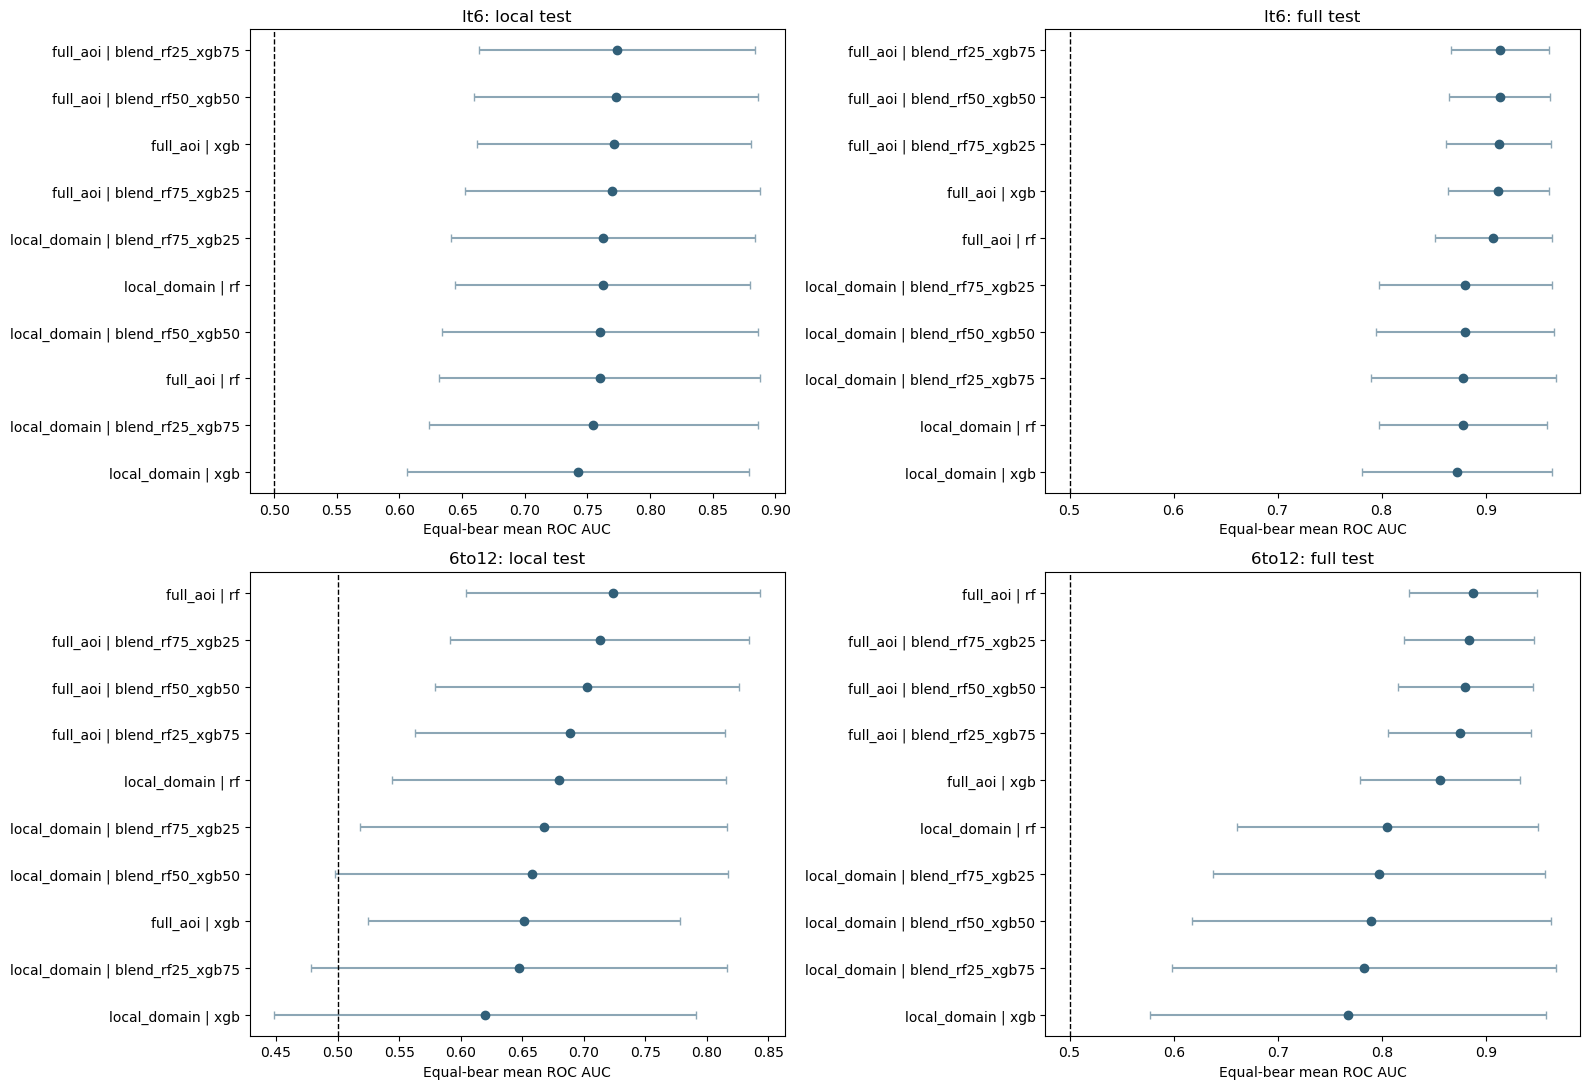

In [32]:
plot_table = loio_summary.copy()
plot_table["label"] = plot_table["training_domain"] + " | " + plot_table["candidate"]

fig, axes = plt.subplots(2, 2, figsize=(16, 11), sharex=False)
for row, cub_class in enumerate(CUB_CLASSES):
    for col, scenario in enumerate(("local_test", "full_test")):
        ax = axes[row, col]
        subset = plot_table[
            (plot_table["cub_class"] == cub_class)
            & (plot_table["evaluation_scenario"] == scenario)
        ].sort_values("auc_roc_mean")
        ax.errorbar(
            subset["auc_roc_mean"],
            subset["label"],
            xerr=subset["auc_roc_std"].fillna(0),
            fmt="o",
            color="#315f78",
            ecolor="#8ca6b5",
            capsize=3,
        )
        ax.axvline(0.5, color="black", linestyle="--", linewidth=1)
        ax.set(title=f"{cub_class}: {scenario.replace('_', ' ')}", xlabel="Equal-bear mean ROC AUC", ylabel="")
fig.tight_layout()
fig.savefig(PLOT_DIR / "loio_domain_algorithm_comparison.png", dpi=250)
plt.show()

In [33]:
worst_bear = (
    loio_results.groupby(["cub_class", "training_domain", "candidate", "evaluation_scenario"], as_index=False)
    .agg(worst_auc=("auc_roc", "min"), mean_boyce=("boyce", "mean"))
    .sort_values(["cub_class", "evaluation_scenario", "worst_auc"], ascending=[True, True, False])
)
display(worst_bear)

for winner in winners.itertuples(index=False):
    status = "management-ready" if winner.management_ready else "exploratory"
    print(
        f"{winner.cub_class}: {winner.training_domain} / {winner.candidate}; "
        f"robust floor={winner.robust_floor:.3f}; mean Boyce={winner.mean_boyce:.3f}; {status}."
    )

,cub_class,training_domain,candidate,evaluation_scenario,worst_auc,mean_boyce
6,6to12,full_aoi,rf,full_test,0.830900,-0.255108
4,6to12,full_aoi,blend_rf75_xgb25,full_test,0.822681,-0.420705
2,6to12,full_aoi,blend_rf50_xgb50,full_test,0.813050,-0.479496
0,6to12,full_aoi,blend_rf25_xgb75,full_test,0.798950,-0.427515
8,6to12,full_aoi,xgb,full_test,0.762421,-0.409001
16,6to12,local_domain,rf,full_test,0.612428,-0.368631
14,6to12,local_domain,blend_rf75_xgb25,full_test,0.578700,-0.477958
12,6to12,local_domain,blend_rf50_xgb50,full_test,0.550292,-0.438952
10,6to12,local_domain,blend_rf25_xgb75,full_test,0.524790,-0.440395
18,6to12,local_domain,xgb,full_test,0.500605,-0.395038


6to12: full_aoi / rf; robust floor=0.633; mean Boyce=-0.316; exploratory.
lt6: full_aoi / blend_rf25_xgb75; robust floor=0.656; mean Boyce=0.334; management-ready.


# 8. Final fitting, calibration, and random-split comparison

## 8.1 Final daily-block bootstrap ensembles

After selection, RF and XGBoost are retuned for each cub class and training domain using all available training presences. Ten daily-block bootstrap replicates are fitted by default. The final suitability surface is the mean prediction of these replicates; fold-specific models are retained only for transfer uncertainty and permutation importance.

In [34]:
def fit_final_models(
    model_data: dict[str, dict[str, Any]],
    features: list[str],
    winners: pd.DataFrame,
    config: Any,
    paths: Any,
    logger: logging.Logger,
) -> tuple[dict[str, dict[str, dict[str, list[dict[str, Any]]]]], dict[str, Any]]:
    models: dict[str, dict[str, dict[str, list[dict[str, Any]]]]] = {}
    parameters: dict[str, Any] = {}
    for cub_class in CUB_CLASSES:
        models[cub_class] = {}
        parameters[cub_class] = {}
        data = model_data[cub_class]
        for domain, pool_name in (("full_aoi", "full_train"), ("local_domain", "local_train")):
            table = pd.concat([data["presences"], data[pool_name]], ignore_index=True)
            models[cub_class][domain] = {}
            parameters[cub_class][domain] = {}
            for algorithm in ["rf"] + (["xgb"] if config.run_xgboost and xgboost is not None else []):
                params = tune_algorithm(algorithm, table, features, f"final_{cub_class}_{domain}_{algorithm}", config, logger)
                parameters[cub_class][domain][algorithm] = params
                ensemble = []
                for replicate in range(config.n_final_bootstrap_replicates):
                    boot = daily_block_bootstrap(data["presences"], config.random_seed + 50_000 + replicate)
                    ensemble.append(fit_bundle(algorithm, pd.concat([boot, data[pool_name]], ignore_index=True), features, params))
                models[cub_class][domain][algorithm] = ensemble
                destination = paths.models / f"ensemble_{cub_class}_{domain}_{algorithm}.pkl"
                if joblib is not None:
                    joblib.dump(ensemble, destination)
                else:
                    destination.write_bytes(pickle.dumps(ensemble))
    (paths.models / "tuned_params.json").write_text(json.dumps(parameters, indent=2, default=str))
    (paths.models / "winner_selection.json").write_text(winners.to_json(orient="records", indent=2))
    return models, parameters


def fit_score_calibrator(oof: pd.DataFrame) -> dict[str, Any]:
    y = oof["label"].astype(int).to_numpy()
    scores = oof["score"].astype(float).to_numpy()
    weights = _evaluation_weights(oof)
    if len(np.unique(scores)) >= 10 and y.sum() >= 20:
        isotonic = IsotonicRegression(out_of_bounds="clip")
        isotonic.fit(scores, y, sample_weight=weights)
        calibrated = isotonic.predict(scores)
        if np.unique(np.round(calibrated, 8)).size >= 3:
            return {"method": "isotonic", "model": isotonic}
    logistic = LogisticRegression(random_state=42)
    logistic.fit(scores.reshape(-1, 1), y, sample_weight=weights)
    return {"method": "logistic", "model": logistic}


def calibrate_scores(calibrator: dict[str, Any], scores: np.ndarray) -> np.ndarray:
    values = np.asarray(scores, dtype=float)
    if calibrator["method"] == "isotonic":
        return np.asarray(calibrator["model"].predict(values), dtype=float)
    return calibrator["model"].predict_proba(values.reshape(-1, 1))[:, 1]


def paper_style_random_validation(
    model_data: dict[str, dict[str, Any]],
    features: list[str],
    winners: pd.DataFrame,
    parameters: dict[str, Any],
    config: Any,
) -> pd.DataFrame:
    records = []
    rng = np.random.default_rng(config.random_seed + 70_000)
    for winner in winners.itertuples(index=False):
        cub_class = winner.cub_class
        domain = winner.training_domain
        candidate = winner.candidate
        pool_name = "local_train" if domain == "local_domain" else "full_train"
        presences = model_data[cub_class]["presences"]
        background = model_data[cub_class][pool_name]
        for repeat in range(config.n_paper_validation_repeats):
            presence_test_ids = rng.choice(len(presences), max(1, math.ceil(0.25 * len(presences))), replace=False)
            background_test_ids = rng.choice(len(background), max(1, math.ceil(0.25 * len(background))), replace=False)
            presence_test_mask = np.zeros(len(presences), dtype=bool)
            background_test_mask = np.zeros(len(background), dtype=bool)
            presence_test_mask[presence_test_ids] = True
            background_test_mask[background_test_ids] = True
            train = pd.concat([presences.loc[~presence_test_mask], background.loc[~background_test_mask]], ignore_index=True)
            test = pd.concat([presences.loc[presence_test_mask], background.loc[background_test_mask]], ignore_index=True)
            ensembles = {}
            rf_weight, xgb_weight = candidate_components(candidate)
            if rf_weight:
                ensembles["rf"] = [fit_bundle("rf", train, features, parameters[cub_class][domain]["rf"])]
            if xgb_weight:
                ensembles["xgb"] = [fit_bundle("xgb", train, features, parameters[cub_class][domain]["xgb"])]
            metrics = evaluate_predictions(test["label"], predict_candidate(candidate, ensembles, test), _evaluation_weights(test))
            records.append(
                {
                    "cub_class": cub_class,
                    "training_domain": domain,
                    "candidate": candidate,
                    "repeat": repeat + 1,
                    "validation_design": "paper_style_random_75_25",
                    **metrics,
                }
            )
    return pd.DataFrame(records)

In [35]:
final_models, final_parameters = fit_final_models(
    model_data,
    feature_cols,
    winners,
    config,
    paths,
    logger,
)
display(pd.DataFrame(winners[["cub_class", "training_domain", "candidate", "reliability_status"]]))

2026-06-14 11:54:36,355 | INFO | final_lt6_full_aoi_rf RF candidate 1/12 AUC=0.914
2026-06-14 11:54:48,643 | INFO | final_lt6_full_aoi_rf RF candidate 2/12 AUC=0.889
2026-06-14 11:55:03,951 | INFO | final_lt6_full_aoi_rf RF candidate 3/12 AUC=0.906
2026-06-14 11:55:10,518 | INFO | final_lt6_full_aoi_rf RF candidate 4/12 AUC=0.917
2026-06-14 11:55:21,238 | INFO | final_lt6_full_aoi_rf RF candidate 5/12 AUC=0.896
2026-06-14 11:55:30,622 | INFO | final_lt6_full_aoi_rf RF candidate 6/12 AUC=0.920
2026-06-14 11:55:36,423 | INFO | final_lt6_full_aoi_rf RF candidate 7/12 AUC=0.886
2026-06-14 11:55:51,774 | INFO | final_lt6_full_aoi_rf RF candidate 8/12 AUC=0.905
2026-06-14 11:56:02,475 | INFO | final_lt6_full_aoi_rf RF candidate 9/12 AUC=0.900
2026-06-14 11:56:07,513 | INFO | final_lt6_full_aoi_rf RF candidate 10/12 AUC=0.905
2026-06-14 11:56:19,759 | INFO | final_lt6_full_aoi_rf RF candidate 11/12 AUC=0.915
2026-06-14 11:56:26,341 | INFO | final_lt6_full_aoi_rf RF candidate 12/12 AUC=0.911
[

,cub_class,training_domain,candidate,reliability_status
0,6to12,full_aoi,rf,exploratory
1,lt6,full_aoi,blend_rf25_xgb75,management_ready


## 8.2 Out-of-fold calibration

Calibration is learned exclusively from out-of-fold predictions. Isotonic regression is used when it yields a sufficiently non-degenerate monotonic mapping; logistic calibration is the fallback. The resulting values are interpreted as relative suitability scores rather than true occurrence probabilities.

Because background prevalence is imposed by sampling, the class-balanced Brier score is the appropriate primary calibration diagnostic. Unweighted Brier scores are also shown to make the effect of prevalence weighting transparent.

In [36]:
calibrators = {}
calibration_records = []
for winner in winners.itertuples(index=False):
    scenario = "local_test" if winner.training_domain == "local_domain" else "full_test"
    selected = oof_predictions[
        (oof_predictions["cub_class"] == winner.cub_class)
        & (oof_predictions["training_domain"] == winner.training_domain)
        & (oof_predictions["candidate"] == winner.candidate)
        & (oof_predictions["evaluation_scenario"] == scenario)
    ].copy()
    calibrator = fit_score_calibrator(selected)
    calibrators[winner.cub_class] = calibrator
    calibrated = calibrate_scores(calibrator, selected["score"].to_numpy())
    balanced_weights = _evaluation_weights(selected)
    calibration_records.append(
        {
            "cub_class": winner.cub_class,
            "method": calibrator["method"],
            "scenario": scenario,
            "raw_brier_balanced": brier_score_loss(selected["label"], selected["score"], sample_weight=balanced_weights),
            "calibrated_brier_balanced": brier_score_loss(selected["label"], calibrated, sample_weight=balanced_weights),
            "raw_brier_unweighted": brier_score_loss(selected["label"], selected["score"]),
            "calibrated_brier_unweighted": brier_score_loss(selected["label"], calibrated),
        }
    )
    destination = MODEL_DIR / f"calibrator_{winner.cub_class}.pkl"
    joblib.dump(calibrator, destination) if joblib is not None else destination.write_bytes(pickle.dumps(calibrator))

calibration_summary = pd.DataFrame(calibration_records)
calibration_summary["balanced_brier_improvement"] = (
    calibration_summary["raw_brier_balanced"] - calibration_summary["calibrated_brier_balanced"]
)
calibration_summary.to_csv(TABLE_DIR / "calibration_summary.csv", index=False)
display(calibration_summary)

,cub_class,method,scenario,raw_brier_balanced,calibrated_brier_balanced,raw_brier_unweighted,calibrated_brier_unweighted,balanced_brier_improvement
0,6to12,isotonic,full_test,0.416749,0.146300,0.089225,0.177905,0.270449
1,lt6,isotonic,full_test,0.326741,0.179815,0.062799,0.188491,0.146926


## 8.3 Repeated 75/25 random validation

Repeated random splitting is provided to facilitate comparison with common habitat-modelling studies. It is not used for final selection because fixes from the same bear and nearby trajectory segments can be represented in both subsets, producing optimistic performance estimates.

In [37]:
paper_validation = paper_style_random_validation(
    model_data,
    feature_cols,
    winners,
    final_parameters,
    config,
)
paper_validation.to_csv(TABLE_DIR / "paper_style_random_validation.csv", index=False)

paper_summary = paper_validation.groupby("cub_class")[["auc_roc", "auc_pr", "boyce", "brier", "tss"]].agg(["mean", "std"])
display(paper_summary)

loio_winner_summary = winners[["cub_class", "auc_roc_mean_local", "auc_roc_mean_full", "auc_roc_min_local"]].copy()
random_auc = paper_validation.groupby("cub_class", as_index=False)["auc_roc"].mean().rename(columns={"auc_roc": "random_75_25_auc"})
validation_comparison = loio_winner_summary.merge(random_auc, on="cub_class")
display(validation_comparison)

auc_roc              auc_pr               boyce            \
               mean       std      mean       std      mean       std   
cub_class                                                               
6to12      0.977114  0.003742  0.974089  0.004374  0.995152  0.006259   
lt6        0.965212  0.004499  0.963797  0.004640  0.932949  0.048960   

              brier                 tss            
               mean       std      mean       std  
cub_class                                          
6to12      0.097123  0.009760  0.871609  0.013023  
lt6        0.085060  0.003935  0.803041  0.014044

,cub_class,auc_roc_mean_local,auc_roc_mean_full,auc_roc_min_local,random_75_25_auc
0,6to12,0.723745,0.887257,0.633030,0.977114
1,lt6,0.773284,0.913748,0.655757,0.965212


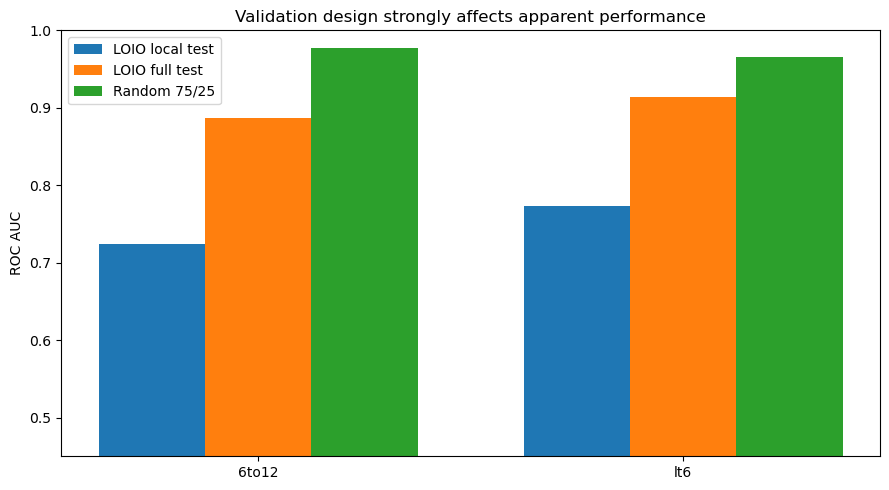

In [38]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(validation_comparison))
width = 0.25
ax.bar(x - width, validation_comparison["auc_roc_mean_local"], width, label="LOIO local test")
ax.bar(x, validation_comparison["auc_roc_mean_full"], width, label="LOIO full test")
ax.bar(x + width, validation_comparison["random_75_25_auc"], width, label="Random 75/25")
ax.set_xticks(x, validation_comparison["cub_class"])
ax.set_ylim(0.45, 1.0)
ax.set(ylabel="ROC AUC", title="Validation design strongly affects apparent performance")
ax.legend()
fig.tight_layout()
fig.savefig(PLOT_DIR / "validation_design_comparison.png", dpi=250)
plt.show()

# 9. Spatial prediction, novelty, and uncertainty

## 9.1 Windowed full-AOI prediction

Prediction is processed in raster windows to control memory use. For each cub class, the representative final-map season is spring for cubs younger than six months and summer for cubs from six to twelve months. This biological convention affects the final maps only; observation-level training still uses the season associated with every GPS date.

All GeoTIFF outputs preserve the original EPSG:3035 grid. Presentation figures are reprojected to EPSG:4326 without replacing the analytical rasters.

In [39]:
def prediction_sources(inventory: pd.DataFrame, features: list[str], season: str) -> list[dict[str, Any]]:
    sources = []
    for feature in features:
        source_name = "topography_aspect" if feature.startswith("topography_aspect_") else feature
        rows = inventory[inventory["model_variable"] == source_name]
        static = rows[rows["temporal_role"].isin(["static", "annual"])]
        if not static.empty:
            sources.append({"feature": feature, "kind": "path", "path": Path(static.iloc[0]["path"]), "transform": feature})
            continue
        seasonal = rows[(rows["temporal_role"] == "seasonal") & (rows["temporal_dimension"].astype(str) == season)]
        if not seasonal.empty:
            sources.append({"feature": feature, "kind": "path", "path": Path(seasonal.iloc[0]["path"]), "transform": None})
            continue
        if source_name == "climate_snow_cover" and season in {"summer", "autumn"}:
            sources.append({"feature": feature, "kind": "constant", "value": 0.0, "transform": None})
            continue
        raise ValueError(f"No {season} raster source for {feature}")
    return sources


def _window_feature_frame(
    sources: list[dict[str, Any]],
    open_sources: dict[str, rasterio.io.DatasetReader],
    window: Window,
    features: list[str],
) -> pd.DataFrame:
    columns = []
    for source in sources:
        if source["kind"] == "constant":
            array = np.full((int(window.height), int(window.width)), source["value"], dtype=float)
        else:
            dataset = open_sources[str(source["path"])]
            array = dataset.read(1, window=window).astype(float)
            if dataset.nodata is not None:
                array[np.isclose(array, dataset.nodata)] = np.nan
        if source["transform"] == "topography_aspect_sin":
            array = np.sin(np.deg2rad(array))
        elif source["transform"] == "topography_aspect_cos":
            array = np.cos(np.deg2rad(array))
        columns.append(array.reshape(-1))
    return pd.DataFrame(np.column_stack(columns), columns=features)


def _write_array_raster(path: Path, array: np.ndarray, profile: dict[str, Any], nodata: float = -9999.0):
    output = np.asarray(array)
    result_profile = profile.copy()
    result_profile.update(dtype="float32", count=1, nodata=nodata, compress="lzw")
    with rasterio.open(path, "w", **result_profile) as dst:
        dst.write(output.astype("float32"), 1)


def normalize_uncertainty_components(component_paths: list[Path], output_path: Path):
    arrays = []
    profile = None
    for path in component_paths:
        with rasterio.open(path) as src:
            array = src.read(1).astype(float)
            valid = np.isfinite(array) & ~np.isclose(array, src.nodata)
            scaled = np.full(array.shape, np.nan)
            if valid.any():
                scale = np.nanpercentile(array[valid], 95)
                scaled[valid] = np.clip(array[valid] / max(scale, 1e-9), 0, 1)
            arrays.append(scaled)
            profile = src.profile.copy()
    combined = np.nanmean(np.stack(arrays), axis=0)
    combined[~np.isfinite(combined)] = -9999.0
    _write_array_raster(output_path, combined, profile)


def predict_official_products(
    cub_class: str,
    winner: pd.Series,
    models: dict[str, dict[str, list[dict[str, Any]]]],
    fold_models: dict[tuple[str, str, str, str], dict[str, Any]],
    model_data: dict[str, Any],
    features: list[str],
    inventory: pd.DataFrame,
    common_mask: np.ndarray,
    grid_path: Path,
    calibrator: dict[str, Any],
    config: Any,
    paths: Any,
) -> dict[str, Path]:
    domain = winner["training_domain"]
    candidate = winner["candidate"]
    season = config.prediction_season_by_class[cub_class]
    sources = prediction_sources(inventory, features, season)
    open_sources = {str(source["path"]): rasterio.open(source["path"]) for source in sources if source["kind"] == "path"}
    with rasterio.open(grid_path) as grid:
        profile = grid.profile.copy()
        height, width = grid.shape
        rows_per_batch = max(1, config.batch_size // width)
    train_pool = "local_train" if domain == "local_domain" else "full_train"
    train = pd.concat([model_data["presences"], model_data[train_pool]], ignore_index=True)
    minima = train[features].min().to_numpy(float)
    maxima = train[features].max().to_numpy(float)
    spans = np.maximum(maxima - minima, 1e-9)
    bears = sorted(model_data["presences"]["bear_name"].unique())
    outputs = {
        "raw": paths.maps / f"diagnostic_raw_suitability_{cub_class}.tif",
        "official": paths.maps / f"official_suitability_{cub_class}.tif",
        "bootstrap": paths.maps / f"uncertainty_bootstrap_{cub_class}.tif",
        "individual": paths.maps / f"uncertainty_individual_{cub_class}.tif",
        "algorithm": paths.maps / f"uncertainty_algorithm_{cub_class}.tif",
        "domain": paths.maps / f"uncertainty_domain_{cub_class}.tif",
        "mess": paths.maps / f"environmental_mess_{cub_class}.tif",
        "outside": paths.maps / f"outside_range_predictor_count_{cub_class}.tif",
    }
    result_profile = profile.copy()
    result_profile.update(dtype="float32", count=1, nodata=-9999.0, compress="lzw")
    writers = {key: rasterio.open(path, "w", **result_profile) for key, path in outputs.items()}
    try:
        for row_start in range(0, height, rows_per_batch):
            n_rows = min(rows_per_batch, height - row_start)
            window = Window(0, row_start, width, n_rows)
            frame = _window_feature_frame(sources, open_sources, window, features)
            valid = common_mask[row_start : row_start + n_rows].reshape(-1) & frame.notna().all(axis=1).to_numpy()
            values = {key: np.full(len(frame), -9999.0, dtype="float32") for key in outputs}
            if valid.any():
                valid_frame = frame.loc[valid]
                mean, bootstrap_std, rf_matrix, xgb_matrix = predict_candidate(
                    candidate,
                    models[domain],
                    valid_frame,
                    return_components=True,
                )
                calibrated = calibrate_scores(calibrator, mean)
                data = valid_frame.to_numpy(float)
                below = (minima - data) / spans
                above = (data - maxima) / spans
                outside = ((data < minima) | (data > maxima)).sum(axis=1)
                signed = np.where(data < minima, -below, np.where(data > maxima, -above, np.minimum((data - minima) / spans, (maxima - data) / spans)))
                mess = np.min(signed, axis=1)

                fold_predictions = []
                for bear in bears:
                    component_ensembles = {}
                    rf_weight, xgb_weight = candidate_components(candidate)
                    if rf_weight:
                        component_ensembles["rf"] = fold_models[(domain, cub_class, "rf", bear)]["ensemble"]
                    if xgb_weight:
                        component_ensembles["xgb"] = fold_models[(domain, cub_class, "xgb", bear)]["ensemble"]
                    fold_predictions.append(predict_candidate(candidate, component_ensembles, valid_frame))
                individual_std = np.std(np.vstack(fold_predictions), axis=0)
                algorithm_disagreement = (
                    np.abs(rf_matrix.mean(axis=0) - xgb_matrix.mean(axis=0))
                    if rf_matrix is not None and xgb_matrix is not None
                    else np.zeros(len(valid_frame))
                )
                other_domain = "local_domain" if domain == "full_aoi" else "full_aoi"
                domain_disagreement = np.abs(mean - predict_candidate(candidate, models[other_domain], valid_frame))
                official = calibrated.copy()
                if domain == "local_domain":
                    official[outside > 0] = -9999.0
                values["raw"][valid] = mean
                values["official"][valid] = official
                values["bootstrap"][valid] = bootstrap_std
                values["individual"][valid] = individual_std
                values["algorithm"][valid] = algorithm_disagreement
                values["domain"][valid] = domain_disagreement
                values["mess"][valid] = mess
                values["outside"][valid] = outside
            for key, writer in writers.items():
                writer.write(values[key].reshape(n_rows, width), 1, window=window)
    finally:
        for writer in writers.values():
            writer.close()
        for source in open_sources.values():
            source.close()
    outputs["relative"] = paths.maps / f"relative_uncertainty_{cub_class}.tif"
    normalize_uncertainty_components(
        [outputs["bootstrap"], outputs["individual"], outputs["algorithm"], outputs["domain"]],
        outputs["relative"],
    )
    return outputs

## 9.2 Environmental novelty and uncertainty components

Two extrapolation diagnostics are produced: a MESS-like environmental novelty surface and the number of predictors outside their training ranges. If a local-domain model wins, environmentally novel cells are masked in the official map while the diagnostic raw surface remains available.

Uncertainty is decomposed into daily-bootstrap variability, disagreement among held-out-individual models, RF/XGBoost disagreement, and full/local-domain disagreement. After robust scaling, their mean forms a relative uncertainty index. This is a comparative warning surface, not a statistical confidence interval.

In [40]:
spatial_outputs = {}
if config.run_map_prediction:
    for _, winner in winners.iterrows():
        cub_class = winner["cub_class"]
        spatial_outputs[cub_class] = predict_official_products(
            cub_class,
            winner,
            final_models[cub_class],
            fold_models,
            model_data[cub_class],
            feature_cols,
            inventory,
            common_mask,
            GRID_PATH,
            calibrators[cub_class],
            config,
            paths,
        )

pd.DataFrame(
    [
        {"cub_class": cub_class, "product": product, "path": str(path)}
        for cub_class, products in spatial_outputs.items()
        for product, path in products.items()
    ]
)

/tmp/ipykernel_175811/1562098256.py:65: RuntimeWarning: Mean of empty slice
  combined = np.nanmean(np.stack(arrays), axis=0)
/tmp/ipykernel_175811/1562098256.py:65: RuntimeWarning: Mean of empty slice
  combined = np.nanmean(np.stack(arrays), axis=0)


,cub_class,product,path
0,6to12,raw,/mnt/csl/work/aniol.garriga.torra/pirineus_ras...
1,6to12,official,/mnt/csl/work/aniol.garriga.torra/pirineus_ras...
2,6to12,bootstrap,/mnt/csl/work/aniol.garriga.torra/pirineus_ras...
3,6to12,individual,/mnt/csl/work/aniol.garriga.torra/pirineus_ras...
4,6to12,algorithm,/mnt/csl/work/aniol.garriga.torra/pirineus_ras...
5,6to12,domain,/mnt/csl/work/aniol.garriga.torra/pirineus_ras...
6,6to12,mess,/mnt/csl/work/aniol.garriga.torra/pirineus_ras...
7,6to12,outside,/mnt/csl/work/aniol.garriga.torra/pirineus_ras...
8,6to12,relative,/mnt/csl/work/aniol.garriga.torra/pirineus_ras...
9,lt6,raw,/mnt/csl/work/aniol.garriga.torra/pirineus_ras...


# 10. Habitat zones, interpretation, and independent validation

## 10.1 Continuous suitability and CARTOBIO zone thresholds

Continuous suitability is the principal scientific output. Categorical zones are derived products and depend on the selected threshold procedure.

The paper-compatible threshold sequence starts with the mean score of the worst 10% of presences, then calculates the mean map suitability above that threshold and repeats the operation for the highest class. The official conservative version applies the same recurrence using calibrated out-of-fold presence scores and the calibrated final map. Connected patches smaller than 0.5 km² are removed.

In [41]:
def map_mean_above(path: Path, threshold: float) -> float:
    total = 0.0
    count = 0
    with rasterio.open(path) as src:
        for _, window in src.block_windows(1):
            data = src.read(1, window=window).astype(float)
            valid = np.isfinite(data) & ~np.isclose(data, src.nodata) & (data >= threshold)
            total += float(data[valid].sum())
            count += int(valid.sum())
    return total / count if count else float(threshold)


def cartobio_thresholds(presence_scores: Iterable[float], map_path: Path) -> dict[str, float]:
    scores = np.sort(np.asarray(list(presence_scores), dtype=float))
    scores = scores[np.isfinite(scores)]
    if not len(scores):
        raise ValueError("No finite presence scores for CARTOBIO thresholds.")
    worst_count = max(1, math.ceil(0.10 * len(scores)))
    adequate = float(scores[:worst_count].mean())
    good = map_mean_above(map_path, adequate)
    optimal = map_mean_above(map_path, good)
    return {"adequate": adequate, "good": good, "optimal": optimal}


def remove_small_patches(mask: np.ndarray, pixel_area_km2: float, minimum_km2: float = 0.5) -> np.ndarray:
    minimum_pixels = max(1, math.ceil(minimum_km2 / pixel_area_km2))
    labels, count = ndimage.label(mask, structure=np.ones((3, 3), dtype=bool))
    if not count:
        return mask
    sizes = np.bincount(labels.ravel())
    keep = sizes >= minimum_pixels
    keep[0] = False
    return keep[labels]


def classify_zones(suitability_path: Path, thresholds: dict[str, float], output_path: Path) -> pd.DataFrame:
    with rasterio.open(suitability_path) as src:
        suitability = src.read(1).astype(float)
        valid = np.isfinite(suitability) & ~np.isclose(suitability, src.nodata)
        pixel_area = abs(src.transform.a * src.transform.e) / 1_000_000
        profile = src.profile.copy()
    masks = {
        name: remove_small_patches(valid & (suitability >= threshold), pixel_area)
        for name, threshold in thresholds.items()
    }
    zones = np.full(suitability.shape, 255, dtype="uint8")
    zones[valid] = 0
    for value, name in enumerate(("adequate", "good", "optimal"), start=1):
        zones[masks[name]] = value
    profile.update(dtype="uint8", nodata=255, compress="lzw")
    with rasterio.open(output_path, "w", **profile) as dst:
        dst.write(zones, 1)
    records = []
    for value, name in enumerate(("adequate", "good", "optimal"), start=1):
        records.append({"zone": name, "area_type": "exclusive", "area_km2": float((zones == value).sum() * pixel_area)})
        records.append({"zone": name, "area_type": "cumulative", "area_km2": float(((zones != 255) & (zones >= value)).sum() * pixel_area)})
    return pd.DataFrame(records)


def plot_raster_4326(
    path: Path,
    output_path: Path,
    title: str,
    bounds_4326: dict[str, float],
    categorical: bool = False,
):
    with rasterio.open(path) as src:
        with WarpedVRT(src, crs="EPSG:4326", resampling=Resampling.nearest if categorical else Resampling.bilinear) as vrt:
            scale = max(vrt.width / 1_600, vrt.height / 900, 1)
            data = vrt.read(
                1,
                out_shape=(max(1, int(vrt.height / scale)), max(1, int(vrt.width / scale))),
                masked=True,
            )
            extent = (vrt.bounds.left, vrt.bounds.right, vrt.bounds.bottom, vrt.bounds.top)
    fig, ax = plt.subplots(figsize=(12, 6.5))
    image = ax.imshow(data, extent=extent, origin="upper", cmap="plasma" if categorical else "viridis")
    ax.set(title=title, xlabel="Longitude (EPSG:4326)", ylabel="Latitude (EPSG:4326)")
    ax.set_xlim(bounds_4326["xmin"], bounds_4326["xmax"])
    ax.set_ylim(bounds_4326["ymin"], bounds_4326["ymax"])
    fig.colorbar(image, ax=ax, fraction=0.035, pad=0.02)
    fig.tight_layout()
    fig.savefig(output_path, dpi=250)
    plt.close(fig)

In [42]:
threshold_records = []
zone_area_tables = []

if config.run_map_prediction:
    for _, winner in winners.iterrows():
        cub_class = winner["cub_class"]
        domain = winner["training_domain"]
        candidate = winner["candidate"]
        products = spatial_outputs[cub_class]

        raw_presence_scores = predict_candidate(
            candidate,
            final_models[cub_class][domain],
            model_data[cub_class]["presences"],
        )
        scenario = "local_test" if domain == "local_domain" else "full_test"
        winning_oof_presences = oof_predictions[
            (oof_predictions["cub_class"] == cub_class)
            & (oof_predictions["training_domain"] == domain)
            & (oof_predictions["candidate"] == candidate)
            & (oof_predictions["evaluation_scenario"] == scenario)
            & (oof_predictions["label"] == 1)
        ]
        calibrated_oof_presences = calibrate_scores(
            calibrators[cub_class], winning_oof_presences["score"].to_numpy()
        )

        paper_thresholds = cartobio_thresholds(raw_presence_scores, products["raw"])
        conservative_thresholds = cartobio_thresholds(calibrated_oof_presences, products["official"])
        threshold_records.extend(
            [
                {"cub_class": cub_class, "threshold_set": "paper_compatible", **paper_thresholds},
                {"cub_class": cub_class, "threshold_set": "conservative_oof_calibrated", **conservative_thresholds},
            ]
        )

        official_zone_path = MAP_DIR / f"official_zones_{cub_class}.tif"
        paper_zone_path = MAP_DIR / f"diagnostic_paper_compatible_zones_{cub_class}.tif"
        official_area = classify_zones(products["official"], conservative_thresholds, official_zone_path)
        official_area.insert(0, "threshold_set", "conservative_oof_calibrated")
        official_area.insert(0, "cub_class", cub_class)
        paper_area = classify_zones(products["raw"], paper_thresholds, paper_zone_path)
        paper_area.insert(0, "threshold_set", "paper_compatible")
        paper_area.insert(0, "cub_class", cub_class)
        zone_area_tables.extend([official_area, paper_area])

zone_thresholds = pd.DataFrame(threshold_records)
zone_areas = pd.concat(zone_area_tables, ignore_index=True) if zone_area_tables else pd.DataFrame()
zone_thresholds.to_csv(TABLE_DIR / "zone_thresholds.csv", index=False)
zone_areas.to_csv(TABLE_DIR / "zone_areas.csv", index=False)
display(zone_thresholds)
display(zone_areas)

,cub_class,threshold_set,adequate,good,optimal
0,6to12,paper_compatible,0.434656,0.568332,0.661398
1,6to12,conservative_oof_calibrated,0.329134,0.695888,0.769159
2,lt6,paper_compatible,0.476177,0.650912,0.731769
3,lt6,conservative_oof_calibrated,0.361512,0.653948,0.824662


,cub_class,threshold_set,zone,area_type,area_km2
0,6to12,conservative_oof_calibrated,adequate,exclusive,6115.05
1,6to12,conservative_oof_calibrated,adequate,cumulative,19345.64
2,6to12,conservative_oof_calibrated,good,exclusive,1726.51
3,6to12,conservative_oof_calibrated,good,cumulative,13230.59
4,6to12,conservative_oof_calibrated,optimal,exclusive,11504.08
5,6to12,conservative_oof_calibrated,optimal,cumulative,11504.08
6,6to12,paper_compatible,adequate,exclusive,670.69
7,6to12,paper_compatible,adequate,cumulative,1074.65
8,6to12,paper_compatible,good,exclusive,268.73
9,6to12,paper_compatible,good,cumulative,403.96


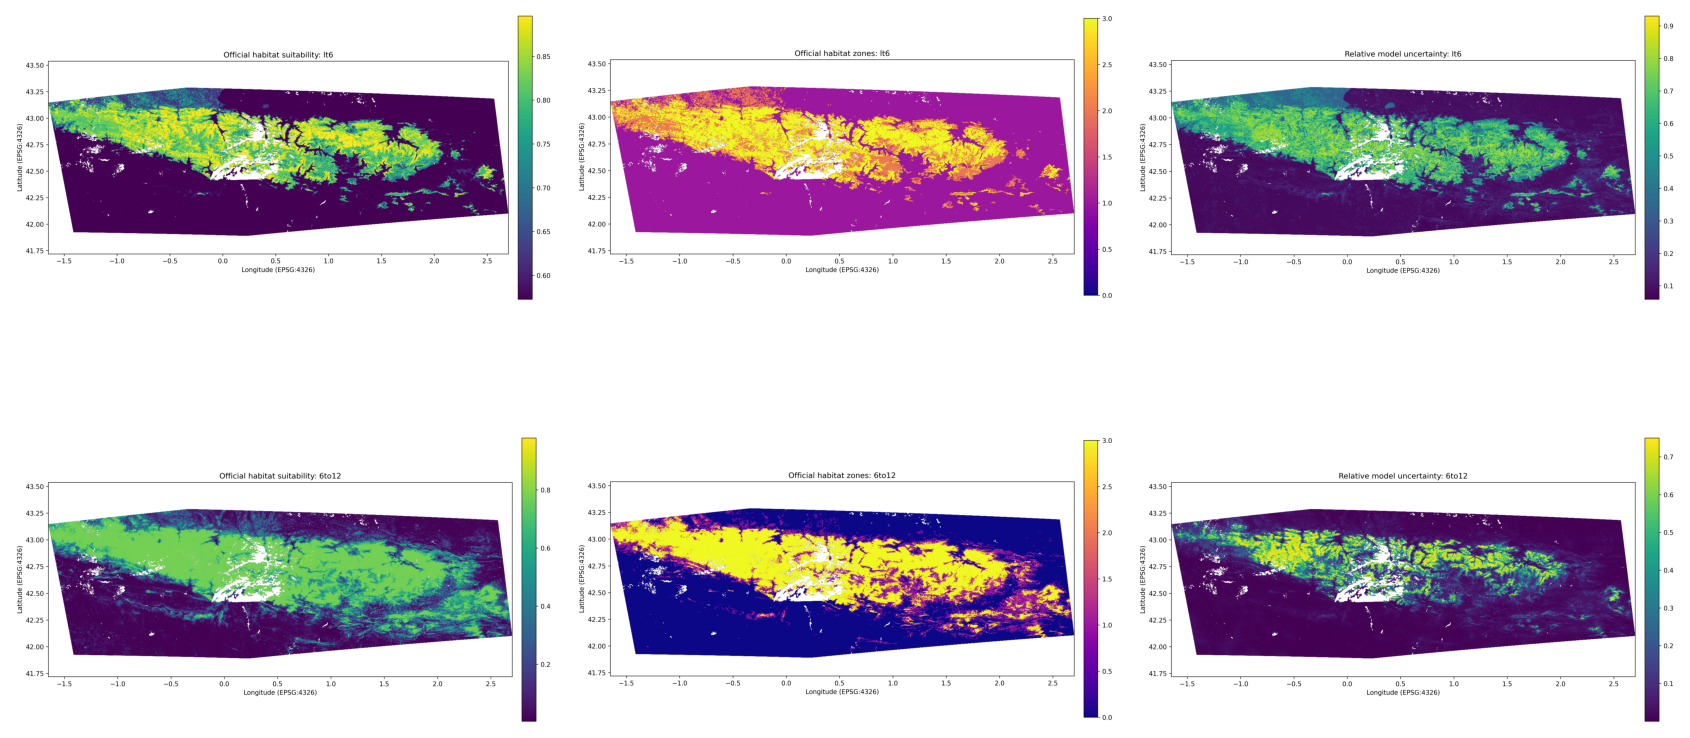

In [43]:
if config.run_map_prediction:
    for cub_class, products in spatial_outputs.items():
        plot_raster_4326(
            products["official"],
            PLOT_DIR / f"official_suitability_{cub_class}_epsg4326.png",
            f"Official habitat suitability: {cub_class}",
            BOUNDS_4326,
        )
        plot_raster_4326(
            MAP_DIR / f"official_zones_{cub_class}.tif",
            PLOT_DIR / f"official_zones_{cub_class}_epsg4326.png",
            f"Official habitat zones: {cub_class}",
            BOUNDS_4326,
            categorical=True,
        )
        plot_raster_4326(
            products["relative"],
            PLOT_DIR / f"relative_uncertainty_{cub_class}_epsg4326.png",
            f"Relative model uncertainty: {cub_class}",
            BOUNDS_4326,
        )

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
for row, cub_class in enumerate(CUB_CLASSES):
    for col, name in enumerate(("official_suitability", "official_zones", "relative_uncertainty")):
        image_path = PLOT_DIR / f"{name}_{cub_class}_epsg4326.png"
        if image_path.exists():
            axes[row, col].imshow(plt.imread(image_path))
        axes[row, col].axis("off")
fig.tight_layout()
plt.show()

## 10.2 Out-of-fold permutation importance and SHAP explanations

Permutation importance measures how much held-out-bear ROC AUC is lost when one predictor is shuffled. It is the primary explanation for a blended candidate because it evaluates the complete prediction rule under transfer conditions.

SHAP summaries are generated separately for RF and XGBoost. They describe the fitted algorithm's local contributions but should not be interpreted as causal effects.

In [44]:
def oof_permutation_importance(
    cub_class: str,
    winner: pd.Series,
    model_data: dict[str, Any],
    features: list[str],
    fold_models: dict[tuple[str, str, str, str], dict[str, Any]],
    config: Any,
) -> pd.DataFrame:
    domain, candidate = winner["training_domain"], winner["candidate"]
    rng = np.random.default_rng(config.random_seed + 80_000)
    records = []
    repeats = 1 if config.smoke_mode else 3
    for bear in sorted(model_data["presences"]["bear_name"].unique()):
        test_presence = model_data["presences"][model_data["presences"]["bear_name"] == bear]
        test = pd.concat([test_presence, model_data["local_test"]], ignore_index=True)
        components = {}
        rf_weight, xgb_weight = candidate_components(candidate)
        if rf_weight:
            components["rf"] = fold_models[(domain, cub_class, "rf", bear)]["ensemble"]
        if xgb_weight:
            components["xgb"] = fold_models[(domain, cub_class, "xgb", bear)]["ensemble"]
        baseline = roc_auc_score(test["label"], predict_candidate(candidate, components, test))
        for feature in features:
            losses = []
            for _ in range(repeats):
                shuffled = test.copy()
                shuffled[feature] = rng.permutation(shuffled[feature].to_numpy())
                losses.append(baseline - roc_auc_score(test["label"], predict_candidate(candidate, components, shuffled)))
            records.append({"cub_class": cub_class, "fold": bear, "feature": feature, "auc_loss": float(np.mean(losses))})
    result = pd.DataFrame(records)
    return result.groupby(["cub_class", "feature"], as_index=False)["auc_loss"].agg(["mean", "std"]).reset_index()


def plot_readable_shap(
    algorithm: str,
    models: dict[str, dict[str, list[dict[str, Any]]]],
    training_domain: str,
    model_data: dict[str, Any],
    features: list[str],
    output_path: Path,
    seed: int,
):
    if shap is None or algorithm not in models[training_domain] or not models[training_domain][algorithm]:
        return
    bundle = models[training_domain][algorithm][0]
    sample = model_data["presences"].sample(min(2_000, len(model_data["presences"])), random_state=seed)
    x = sample[features].fillna(bundle["medians"])
    explainer = shap.TreeExplainer(bundle["model"])
    values = explainer.shap_values(x)
    if isinstance(values, list):
        values = values[-1]
    elif np.ndim(values) == 3:
        values = values[:, :, -1]
    display_x = x.rename(columns=SHORT_FEATURE_LABELS)
    shap.summary_plot(values, display_x, max_display=15, plot_size=(11, 8), show=False)
    plt.gcf().subplots_adjust(left=0.34, right=0.92, bottom=0.12)
    plt.savefig(output_path, dpi=250, bbox_inches="tight")
    plt.close()

In [45]:
importance_tables = []
for _, winner in winners.iterrows():
    cub_class = winner["cub_class"]
    importance = oof_permutation_importance(
        cub_class,
        winner,
        model_data[cub_class],
        feature_cols,
        fold_models,
        config,
    )
    importance_tables.append(importance)

    if config.run_shap:
        for algorithm in ("rf", "xgb"):
            plot_readable_shap(
                algorithm,
                final_models[cub_class],
                winner["training_domain"],
                model_data[cub_class],
                feature_cols,
                PLOT_DIR / f"shap_beeswarm_{cub_class}_{algorithm}.png",
                RANDOM_SEED,
            )

permutation_importance_table = pd.concat(importance_tables, ignore_index=True)
permutation_importance_table.to_csv(TABLE_DIR / "oof_permutation_importance.csv", index=False)
display(
    permutation_importance_table.sort_values(["cub_class", "mean"], ascending=[True, False])
    .groupby("cub_class")
    .head(15)
)

,index,cub_class,feature,mean,std
20,20,6to12,topography_dem_elevation,0.056925,0.014705
21,21,6to12,topography_ruggedness,0.055456,0.018171
5,5,6to12,habitat_biomass_mean,0.028926,0.027888
4,4,6to12,climate_water_availability,0.025370,0.016327
15,15,6to12,human_logdistance_towns,0.023916,0.012922
0,0,6to12,climate_mean_temperature,0.019988,0.008635
14,14,6to12,human_logdistance_secondary_roads_transport_se...,0.016506,0.005448
11,11,6to12,habitat_screes_and_bare_rocks_2018,0.011267,0.003553
6,6,6to12,habitat_broadleaf,0.010046,0.008883
10,10,6to12,habitat_productivity_mean,0.009987,0.007588


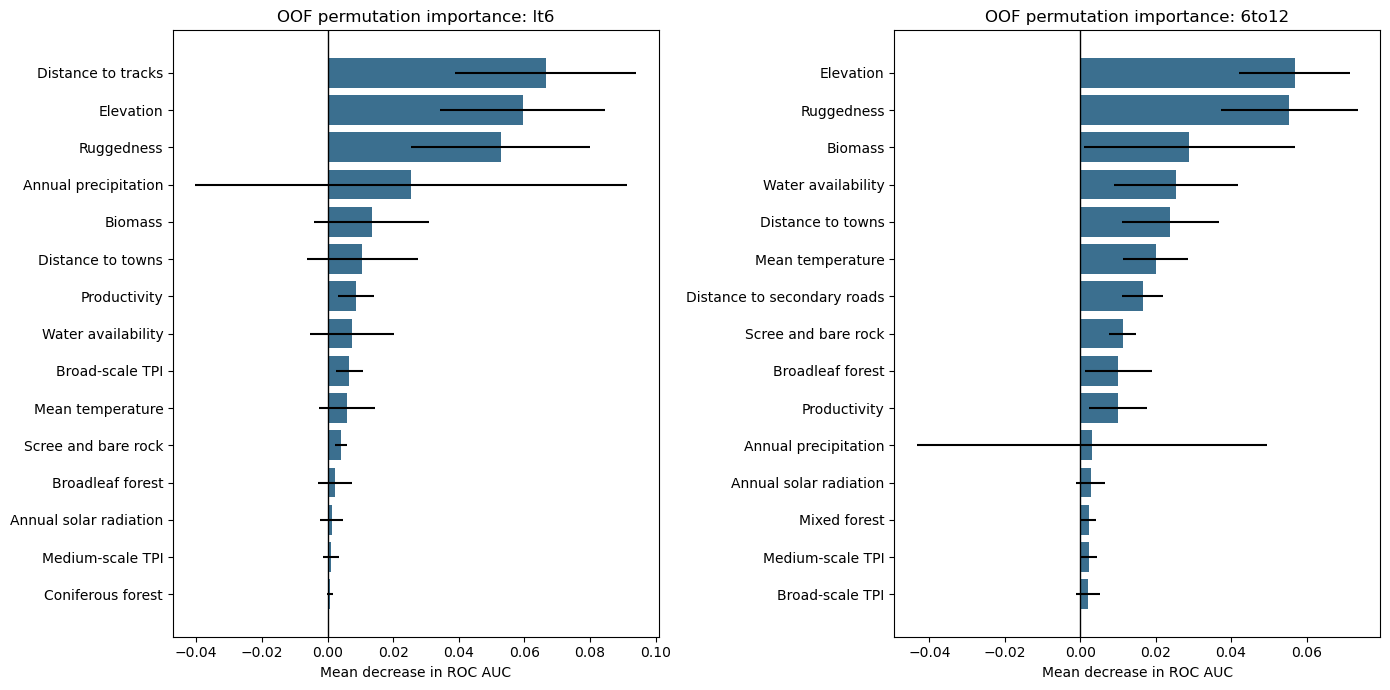

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, cub_class in zip(axes, CUB_CLASSES):
    subset = (
        permutation_importance_table[permutation_importance_table["cub_class"] == cub_class]
        .nlargest(15, "mean")
        .sort_values("mean")
    )
    labels = [SHORT_FEATURE_LABELS.get(feature, feature) for feature in subset["feature"]]
    ax.barh(labels, subset["mean"], xerr=subset["std"].fillna(0), color="#3b6f8f")
    ax.axvline(0, color="black", linewidth=1)
    ax.set(title=f"OOF permutation importance: {cub_class}", xlabel="Mean decrease in ROC AUC")
fig.tight_layout()
fig.savefig(PLOT_DIR / "oof_permutation_importance.png", dpi=250, bbox_inches="tight")
plt.show()

## 10.3 Independent OBS audit

The independently collected OBS records are evaluated only after every modelling decision has been completed. For each cub class, OBS presences are compared with an equal-sized sample from the full-AOI test background. The audit reports discrimination, Boyce index, calibration-sensitive metrics, and a one-sided Mann-Whitney test of whether OBS suitability exceeds background suitability.

In [47]:
def independent_obs_audit(
    obs: pd.DataFrame,
    model_data: dict[str, dict[str, Any]],
    features: list[str],
    winners: pd.DataFrame,
    models: dict[str, dict[str, dict[str, list[dict[str, Any]]]]],
    inventory: pd.DataFrame,
) -> pd.DataFrame:
    records = []
    for winner in winners.itertuples(index=False):
        subset = obs[obs["cub_class"] == winner.cub_class].copy()
        if subset.empty:
            continue
        subset["point_id"] = subset["id_obs"].astype(str)
        subset["label"] = 1
        subset["source"] = "obs"
        subset_features = extract_features(subset, inventory)
        obs_table = pd.concat([subset.reset_index(drop=True), subset_features.reset_index(drop=True)], axis=1)
        obs_table = obs_table.dropna(subset=features)
        background = model_data[winner.cub_class]["full_test"].sample(min(len(obs_table), len(model_data[winner.cub_class]["full_test"])), random_state=42)
        test = pd.concat([obs_table, background], ignore_index=True)
        scores = predict_candidate(winner.candidate, models[winner.cub_class][winner.training_domain], test)
        metrics = evaluate_predictions(test["label"], scores, _evaluation_weights(test))
        positive = scores[test["label"].to_numpy() == 1]
        negative = scores[test["label"].to_numpy() == 0]
        records.append(
            {
                "cub_class": winner.cub_class,
                "training_domain": winner.training_domain,
                "candidate": winner.candidate,
                "n_obs_presence": len(positive),
                "n_background": len(negative),
                "mean_obs_suitability": float(np.mean(positive)),
                "mean_background_suitability": float(np.mean(negative)),
                "mannwhitney_p_greater": float(mannwhitneyu(positive, negative, alternative="greater").pvalue),
                **metrics,
            }
        )
    return pd.DataFrame(records)

,cub_class,training_domain,candidate,n_obs_presence,n_background,mean_obs_suitability,mean_background_suitability,mannwhitney_p_greater,auc_roc,auc_pr,boyce,log_loss,brier,tss,threshold_youden
0,6to12,full_aoi,rf,901,901,0.383369,0.058998,1.471644e-215,0.926019,0.907129,0.975758,0.658454,0.225433,0.715871,0.069161
1,lt6,full_aoi,blend_rf25_xgb75,266,266,0.653660,0.201316,6.242445e-65,0.925321,0.916640,0.963636,0.389533,0.120162,0.721805,0.430288


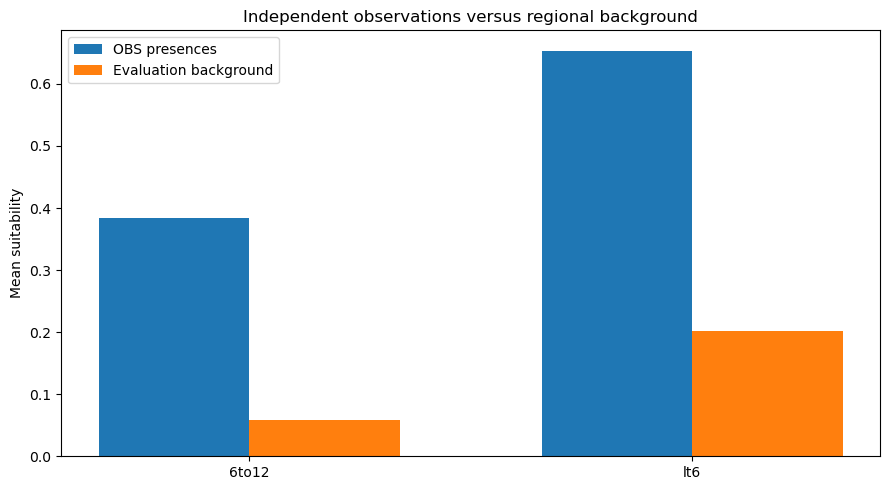

In [48]:
obs_validation = independent_obs_audit(
    obs,
    model_data,
    feature_cols,
    winners,
    final_models,
    inventory,
)
obs_validation.to_csv(TABLE_DIR / "obs_validation.csv", index=False)
display(obs_validation)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(obs_validation))
width = 0.34
ax.bar(x - width / 2, obs_validation["mean_obs_suitability"], width, label="OBS presences")
ax.bar(x + width / 2, obs_validation["mean_background_suitability"], width, label="Evaluation background")
ax.set_xticks(x, obs_validation["cub_class"])
ax.set(ylabel="Mean suitability", title="Independent observations versus regional background")
ax.legend()
fig.tight_layout()
fig.savefig(PLOT_DIR / "obs_independent_validation.png", dpi=250)
plt.show()

# 11. Final verification and conclusions

## 11.1 Reproducibility record and output manifest

The final stage records the effective parameters, current Git revision and working-tree state, source-file sizes and timestamps, domain geometry, and all run-owned outputs. These records make it possible to identify the precise data and code state used for a result.

In [49]:
def write_geojson(geometries: dict[str, Any], path: Path, crs: str):
    content = {
        "type": "FeatureCollection",
        "name": "ursus_arctos_modelling_domains",
        "crs": {"type": "name", "properties": {"name": crs}},
        "features": [
            {"type": "Feature", "properties": {"domain": name}, "geometry": mapping(geometry)}
            for name, geometry in geometries.items()
        ],
    }
    path.write_text(json.dumps(content, indent=2))


def output_manifest(root: Path) -> pd.DataFrame:
    records = []
    for path in sorted(root.rglob("*")):
        if path.is_file() and path.name != "output_manifest.csv":
            records.append(
                {
                    "path": str(path.relative_to(root)),
                    "size_mb": path.stat().st_size / 1_000_000,
                    "modified_utc": pd.to_datetime(path.stat().st_mtime, unit="s", utc=True),
                }
            )
    return pd.DataFrame(records)


def write_run_provenance(project_root: Path, run_root: Path, parameters: dict, input_paths: list[Path]):
    (run_root / "parameters.json").write_text(json.dumps(parameters, indent=2, default=str), encoding="utf-8")
    status = subprocess.run(["git", "status", "--short"], cwd=project_root, capture_output=True, text=True, check=False)
    revision = subprocess.run(["git", "rev-parse", "HEAD"], cwd=project_root, capture_output=True, text=True, check=False)
    (run_root / "git_state.txt").write_text(
        f"commit: {revision.stdout.strip()}\n\n{status.stdout}", encoding="utf-8"
    )
    records = []
    for path in input_paths:
        if path.exists():
            records.append(
                {
                    "path": str(path.relative_to(project_root)),
                    "size_mb": path.stat().st_size / 1_000_000,
                    "modified_utc": pd.to_datetime(path.stat().st_mtime, unit="s", utc=True),
                }
            )
    pd.DataFrame(records).to_csv(run_root / "input_files.csv", index=False)

In [50]:
write_geojson(domain_geometries, INTERMEDIATE_DIR / "modelling_domains.geojson", TARGET_CRS)

input_paths = [
    GPS_PATH,
    OBS_PATH,
    INDIVIDUALS_PATH,
    GRID_PATH,
    AOI_CONFIG_PATH,
    RUN_CONFIG_PATH,
] + [Path(path) for path in inventory["path"]]
write_run_provenance(PROJECT_ROOT, RUN_ROOT, vars(config), input_paths)

official_suitability = sorted(MAP_DIR.glob("official_suitability_*.tif"))
official_zones = sorted(MAP_DIR.glob("official_zones_*.tif"))
if config.run_map_prediction:
    assert len(official_suitability) == 2
    assert len(official_zones) == 2
    for path in official_suitability + official_zones:
        with rasterio.open(path) as source:
            assert str(source.crs) == TARGET_CRS
            assert source.shape == common_mask.shape

manifest = output_manifest(RUN_ROOT)
manifest.to_csv(RUN_ROOT / "output_manifest.csv", index=False)
assert all((RUN_ROOT / relative_path).exists() for relative_path in manifest["path"])

print(f"Run directory: {RUN_ROOT}")
print(f"Manifest entries: {len(manifest)}")
print("Official suitability maps:", [path.name for path in official_suitability])
print("Official zone maps:", [path.name for path in official_zones])

Run directory: /mnt/csl/work/aniol.garriga.torra/pirineus_raster/outputs/ursus_arctos_habitat_modelling/run_3
Manifest entries: 100
Official suitability maps: ['official_suitability_6to12.tif', 'official_suitability_lt6.tif']
Official zone maps: ['official_zones_6to12.tif', 'official_zones_lt6.tif']


## 11.2 Run-specific synthesis

The final interpretation combines the robust LOIO selection criteria with the independent OBS audit. A management-ready label means that the selected candidate also passed the non-negative local Boyce guardrail. An exploratory label identifies the strongest tested candidate but indicates that its categorical zones require additional evidence and expert review.

In [51]:
conclusion_lines = ["### Model conclusions"]
for winner in winners.itertuples(index=False):
    audit = obs_validation.loc[obs_validation["cub_class"] == winner.cub_class].iloc[0]
    readiness = "management-ready under the configured validation guardrail" if winner.management_ready else "exploratory"
    conclusion_lines.append(
        f"- **{winner.cub_class}**: selected **{winner.training_domain} / {winner.candidate}**. "
        f"Local mean ROC AUC = `{winner.auc_roc_mean_local:.3f}`, full-AOI mean ROC AUC = `{winner.auc_roc_mean_full:.3f}`, "
        f"worst-bear local ROC AUC = `{winner.auc_roc_min_local:.3f}`, and mean Boyce = `{winner.mean_boyce:.3f}`. "
        f"The result is **{readiness}**. Independent OBS ROC AUC = `{audit.auc_roc:.3f}` and Boyce = `{audit.boyce:.3f}`."
    )
display(Markdown("\n".join(conclusion_lines)))

### Model conclusions
- **6to12**: selected **full_aoi / rf**. Local mean ROC AUC = `0.724`, full-AOI mean ROC AUC = `0.887`, worst-bear local ROC AUC = `0.633`, and mean Boyce = `-0.316`. The result is **exploratory**. Independent OBS ROC AUC = `0.926` and Boyce = `0.976`.
- **lt6**: selected **full_aoi / blend_rf25_xgb75**. Local mean ROC AUC = `0.773`, full-AOI mean ROC AUC = `0.914`, worst-bear local ROC AUC = `0.656`, and mean Boyce = `0.334`. The result is **management-ready under the configured validation guardrail**. Independent OBS ROC AUC = `0.925` and Boyce = `0.964`.

## 11.3 Scientific interpretation of the final products

- The official continuous rasters represent **relative habitat suitability**, not occurrence probability.
- Categorical zones are conditional on the threshold procedure and must be distributed with the continuous map and threshold table.
- Strong regional AUC can coexist with weaker local or individual transfer. The latter is more informative about generalization to unseen bears.
- Environmental novelty and uncertainty surfaces identify where suitability predictions deserve additional caution.
- The locally accessible domain is data-derived and should be replaced by an expert-defined availability polygon when one becomes available.
- Seasonal predictors represent the environmental period associated with each observation, but historical year-specific environmental reconstruction is not available.
- The limited number of monitored individuals remains the principal constraint on population-level inference.

Within these limitations, the workflow provides a transparent and conservative comparison of modelling alternatives, preserves the available biological data, and distinguishes robust predictions from exploratory results.